# SWH-011 — Kebutuhan Air, Debit, dan Water Loss per Petak

Notebook ini menjawab tiga hal untuk lahan `SWH-011_lengkap.kml`:

1. **Ada berapa petak di file KML ini?** — lalu kebutuhan air **per petak**
2. **Berapa debit** untuk mengairi satu bagian sawah
3. **Berapa water loss** (air menguap, meresap, mengalir keluar) **per petak**

### Sumber angka

| Apa | Dari mana |
|---|---|
| Batas lahan **dan batas tiap petak** | `SWH-011_lengkap.kml` |
| Rumus ETo (Hargreaves) | Arif et al. (2015) pers. (1) — `docs/admin,+14_PIJIC2015_77.pdf` |
| Koefisien tanaman Kc | Arif et al. (2015) Tabel 1 |
| Perkolasi `I = a·h` | Li et al. (2024) pers. (9) — `docs/29_29_2_63.pdf` |
| Limpasan lubang buang | Li et al. (2024) pers. (7)–(8) |
| Persamaan orifice pintu | Li et al. (2024) pers. (4) |
| NFR → DR, penyiapan lahan | KP-01 (Kriteria Perencanaan Irigasi, PUPR) |

> **Petak sudah NYATA.** Beda dengan versi sebelumnya yang memakai `SWH-011.kml`
> (hanya batas luar, petak dibuat grid otomatis), file ini sudah memuat batas tiap
> petak hasil digitasi — jadi jumlah, bentuk, dan luas petak **dibaca dari file**.
>
> **Cuaca masih DUMMY.** Metodenya sudah benar; angka cuaca belum bisa dipakai
> sebelum diganti data lapangan. Daftar asumsi ada di bagian akhir.

## 0. Persiapan

In [21]:
import math, re, json, io as _io, socket, urllib.request
from pathlib import Path
from datetime import date, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patheffects as pe
from matplotlib.patches import Polygon as MplPolygon

pd.set_option("display.width", 150); pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False,
                     "axes.spines.right": False})

# ============================ KONFIGURASI ============================
SEED                  = 20260810     # dikunci -> hasil sama tiap dijalankan
NAMA_KML              = "SWH-011_lengkap.kml"   # batas luar + batas tiap petak
TANGGAL_TANAM         = date(2026, 5, 15)
N_HARI                = 110
EFISIENSI_IRIGASI     = 0.65         # KP-01: 0,90 x 0,90 x 0,80
PERK_KERING_RASIO     = 0.60         # perkolasi saat tak tergenang (rasio dari saat tergenang)
LAMA_ISI_JAM          = 6.0          # target lama pengisian satu petak
KISI_UJI_M            = 0.5          # resolusi uji geometri petak (m)
# =====================================================================

ROOT    = Path.cwd().parent if Path.cwd().name == "note" else Path.cwd()
KML     = ROOT / NAMA_KML
OUT_DIR = ROOT / "note" / "output-swh"; OUT_DIR.mkdir(parents=True, exist_ok=True)
GBR_DIR = OUT_DIR / "gambar"; GBR_DIR.mkdir(parents=True, exist_ok=True)
TILE_DIR = ROOT / "note" / "output" / "tiles"; TILE_DIR.mkdir(parents=True, exist_ok=True)

DPI_GAMBAR = 150
GAMBAR_TERSIMPAN = []

def simpan_gambar(fig, nama, dpi=None):
    '''Simpan satu figure (beserta semua subplot-nya) ke output-swh/gambar/*.png.'''
    berkas = GBR_DIR / f"{nama}.png"
    fig.savefig(berkas, dpi=DPI_GAMBAR if dpi is None else dpi,
                bbox_inches="tight", facecolor="white")
    GAMBAR_TERSIMPAN.append(berkas)
    print(f"[gambar] {berkas.name:<30} {berkas.stat().st_size/1024:>7,.0f} KB")
    return berkas

assert KML.exists(), f"KML tidak ditemukan: {KML}"
print("kml    :", KML.name, f"({KML.stat().st_size:,} byte)")
print("output :", OUT_DIR)
print("gambar :", GBR_DIR)

kml    : SWH-011_lengkap.kml (40,540 byte)
output : d:\WMS_AgrinIrigation\note\output-swh
gambar : d:\WMS_AgrinIrigation\note\output-swh\gambar


---
## 1. Ada berapa petak di file KML ini?

Pertanyaan ini harus dijawab lebih dulu, karena menentukan semua hitungan berikutnya.

KML bisa memuat banyak geometri. Sel di bawah menghitung **semua** yang ada — `Point`,
`LineString`, `Polygon` — tanpa asumsi apa pun.

Bedanya dengan versi lama: `SWH-011.kml` hanya memuat satu batas luar, sehingga jumlah
petak harus **dikarang**. `SWH-011_lengkap.kml` memuat batas luar **plus batas tiap
petak**, jadi jumlah petak sekarang cukup **dibaca**.

In [22]:
raw = KML.read_text(encoding="utf-8")

def ambil_koordinat(blok):
    '''Teks <coordinates> -> daftar (lon, lat).'''
    out = []
    for tok in blok.split():
        bag = tok.split(",")
        if len(bag) >= 2:
            out.append((float(bag[0]), float(bag[1])))
    return out

def luas_derajat(titik):
    '''Luas kasar (derajat^2) - hanya untuk mengurutkan besar-kecil.'''
    x = np.array([p[0] for p in titik]); y = np.array([p[1] for p in titik])
    return 0.5*abs(np.dot(x, np.roll(y, -1)) - np.dot(np.roll(x, -1), y))

geometri = []
for m in re.finditer(r"<Placemark[^>]*>(.*?)</Placemark>", raw, re.S):
    body = m.group(1)
    nama = re.search(r"<name>(.*?)</name>", body, re.S)
    nama = nama.group(1).strip() if nama else "(tanpa nama)"
    # cincin luar poligon; kalau tidak ada, LineString/Point
    luar = re.findall(r"<outerBoundaryIs>\s*<LinearRing>.*?<coordinates>(.*?)</coordinates>",
                      body, re.S)
    dalam = re.findall(r"<innerBoundaryIs>\s*<LinearRing>.*?<coordinates>(.*?)</coordinates>",
                       body, re.S)
    if luar:
        for cd in luar:
            geometri.append({"nama": nama, "tipe": "Polygon",
                             "titik": ambil_koordinat(cd), "lubang": len(dalam)})
    else:
        for tipe in ("LineString", "Point"):
            for g in re.finditer(rf"<{tipe}>(.*?)</{tipe}>", body, re.S):
                for cd in re.finditer(r"<coordinates>(.*?)</coordinates>", g.group(1), re.S):
                    geometri.append({"nama": nama, "tipe": tipe,
                                     "titik": ambil_koordinat(cd.group(1)), "lubang": 0})

print(f"Nama dokumen : {re.findall(r'<Document[^>]*>\s*<name>(.*?)</name>', raw, re.S)[0]}")
print(f"Jumlah Placemark : {len(re.findall(r'<Placemark', raw))}")
print(f"Jumlah geometri  : {len(geometri)}\n")
for g in geometri:
    print(f"  {g['tipe']:<12} | {g['nama']:<12} | {len(g['titik']):>3} simpul | "
          f"{g['lubang']} lubang")

# poligon terluas = batas lahan; sisanya = petak (urutan file dipertahankan)
kandidat  = [g for g in geometri if g["tipe"] == "Polygon" and len(g["titik"]) >= 4]
batas     = max(kandidat, key=lambda g: luas_derajat(g["titik"]))
petak_kml = [g for g in kandidat if g is not batas]
assert petak_kml, "tidak ada poligon petak di dalam KML ini"

print(f"\n{'='*66}")
print(f"  JAWABAN: file KML ini berisi {len(kandidat)} poligon =")
print(f"           1 batas luar ({batas['nama']}) + {len(petak_kml)} PETAK")
print(f"  Nama petak : {petak_kml[0]['nama']} .. {petak_kml[-1]['nama']}")
print(f"  Jumlah petak DIBACA dari file - tidak perlu dikarang lagi.")
print(f"{'='*66}")

Nama dokumen : SWH-011
Jumlah Placemark : 24
Jumlah geometri  : 24

  Polygon      | SWH-011      |  67 simpul | 0 lubang
  Polygon      | PTK-01       |  18 simpul | 0 lubang
  Polygon      | PTK-02       |  24 simpul | 0 lubang
  Polygon      | PTK-03       |  21 simpul | 0 lubang
  Polygon      | PTK-04       |  32 simpul | 0 lubang
  Polygon      | PTK-05       |  37 simpul | 0 lubang
  Polygon      | PTK-06       |  23 simpul | 0 lubang
  Polygon      | PTK-07       |  20 simpul | 0 lubang
  Polygon      | PTK-08       |  16 simpul | 0 lubang
  Polygon      | PTK-09       |  18 simpul | 0 lubang
  Polygon      | PTK-10       |  17 simpul | 0 lubang
  Polygon      | PTK-11       |  17 simpul | 0 lubang
  Polygon      | PTK-12       |  14 simpul | 0 lubang
  Polygon      | PTK-13       |  41 simpul | 0 lubang
  Polygon      | PTK-14       |  32 simpul | 0 lubang
  Polygon      | PTK-15       |  23 simpul | 0 lubang
  Polygon      | PTK-16       |  16 simpul | 0 lubang
  Polygon     

In [23]:
ring_ll = batas["titik"][:]
if (abs(ring_ll[0][0]-ring_ll[-1][0]) < 1e-12 and abs(ring_ll[0][1]-ring_ll[-1][1]) < 1e-12):
    ring_ll = ring_ll[:-1]                       # buang simpul penutup
    print("Cincin batas sudah tertutup rapi (simpul penutup dibuang).")
else:
    d = math.hypot(ring_ll[0][0]-ring_ll[-1][0], ring_ll[0][1]-ring_ll[-1][1]) * 111_000
    print(f"CATATAN: cincin tidak persis tertutup, celah ~{d:.2f} m -> ditutup otomatis.")

lon = np.array([p[0] for p in ring_ll]); lat = np.array([p[1] for p in ring_ll])
lat0, lon0 = float(lat.mean()), float(lon.mean())
phi = math.radians(lat0)
M_PER_DEG_LAT = 111_132.92 - 559.82*math.cos(2*phi) + 1.175*math.cos(4*phi)
M_PER_DEG_LON = 111_412.84*math.cos(phi) - 93.5*math.cos(3*phi)
X = (lon - lon0) * M_PER_DEG_LON
Y = (lat - lat0) * M_PER_DEG_LAT

def ke_meter(titik):
    '''(lon, lat) derajat -> (x, y) meter, acuan sama untuk semua geometri.'''
    return [((lo - lon0)*M_PER_DEG_LON, (la - lat0)*M_PER_DEG_LAT) for lo, la in titik]

for g in petak_kml:                              # petak ikut dipindah ke satuan meter
    t = g["titik"][:]
    if (abs(t[0][0]-t[-1][0]) < 1e-12 and abs(t[0][1]-t[-1][1]) < 1e-12):
        t = t[:-1]
    g["xy"] = ke_meter(t)

n_simpul = [len(g["xy"]) for g in petak_kml]
print(f"\nSimpul batas : {len(ring_ll)}")
print(f"Petak dibaca : {len(petak_kml)} poligon, {min(n_simpul)}-{max(n_simpul)} simpul "
      f"(rata-rata {np.mean(n_simpul):.0f})")
print(f"Titik tengah : {lat0:.6f} LS, {lon0:.6f} BT")
print(f"1 deg lintang = {M_PER_DEG_LAT:,.1f} m | 1 deg bujur = {M_PER_DEG_LON:,.1f} m")

Cincin batas sudah tertutup rapi (simpul penutup dibuang).

Simpul batas : 66
Petak dibaca : 23 poligon, 13-40 simpul (rata-rata 23)
Titik tengah : -7.182543 LS, 107.907941 BT
1 deg lintang = 110,591.6 m | 1 deg bujur = 110,451.6 m


---
## 2. Luas lahan

Koordinat KML satuannya **derajat**, jadi harus diubah ke meter dulu (sudah di atas),
baru dihitung luasnya dengan rumus **Shoelace**.

Konversi satuan luas — semuanya turun dari satu definisi: **1 ha = 10.000 m²**

| Dari | Ke | Kali |
|---|---|---|
| m² | ha | ÷ 10.000 |
| km² | ha | **× 100** |
| ha | m² | × 10.000 |

In [24]:
def luas_shoelace(poly):
    '''Luas poligon (m2) dari daftar titik (x, y) dalam meter.'''
    if len(poly) < 3:
        return 0.0
    x = np.array([p[0] for p in poly], float); y = np.array([p[1] for p in poly], float)
    return 0.5 * abs(np.dot(x, np.roll(y, -1)) - np.dot(np.roll(x, -1), y))

def pusat_poligon(poly):
    '''Titik berat poligon (bukan rata-rata simpul).'''
    x = np.array([q[0] for q in poly], float); y = np.array([q[1] for q in poly], float)
    x2, y2 = np.roll(x, -1), np.roll(y, -1)
    cr = x*y2 - x2*y; A = cr.sum()/2.0
    if abs(A) < 1e-9:
        return float(x.mean()), float(y.mean())
    return float(((x+x2)*cr).sum()/(6*A)), float(((y+y2)*cr).sum()/(6*A))

def luas_geodesik(lon_deg, lat_deg):
    '''Luas di permukaan bola (m2) - untuk cek silang.'''
    R = 6_371_008.8
    la = np.radians(np.asarray(lon_deg, float)); ph = np.radians(np.asarray(lat_deg, float))
    la2, ph2 = np.roll(la, -1), np.roll(ph, -1)
    return abs(np.sum((la2-la)*(2+np.sin(ph)+np.sin(ph2))) * R*R / 2.0)

RING = list(zip(X, Y))
LUAS_M2  = luas_shoelace(RING)
LUAS_HA  = LUAS_M2 / 10_000.0
LUAS_KM2 = LUAS_M2 / 1_000_000.0
Xc, Yc = np.append(X, X[0]), np.append(Y, Y[0])
KELILING = float(np.hypot(np.diff(Xc), np.diff(Yc)).sum())
LUAS_GEO = luas_geodesik(lon, lat)

print("=" * 58)
print(f"           LUAS LAHAN {batas['nama']}")
print("=" * 58)
print(f"  {LUAS_M2:>14,.1f}  m2")
print(f"  {LUAS_HA:>14,.4f}  ha")
print(f"  {LUAS_KM2:>14,.6f}  km2")
print("-" * 58)
print(f"  Keliling        : {KELILING:,.1f} m")
print(f"  Kotak pembatas  : {X.max()-X.min():.0f} m x {Y.max()-Y.min():.0f} m")
print("=" * 58)
print(f"\nCek silang metode bola (geodesik): {LUAS_GEO:,.1f} m2 "
      f"-> selisih {100*abs(LUAS_GEO-LUAS_M2)/LUAS_GEO:.3f} %")

rng_uji = np.random.default_rng(SEED)
As = np.array([luas_shoelace(list(zip(X + rng_uji.normal(0, 1.0, len(X)),
                                      Y + rng_uji.normal(0, 1.0, len(Y)))))
               for _ in range(3000)])
print(f"Ketidakpastian digitasi (galat +/-1 m per simpul): +/- {As.std()/1e4:.4f} ha "
      f"({100*As.std()/LUAS_M2:.2f} %)")
print(f"-> laporkan sebagai {LUAS_HA:.2f} ha, bukan {LUAS_HA:.4f} ha")

           LUAS LAHAN SWH-011
        42,877.4  m2
          4.2877  ha
        0.042877  km2
----------------------------------------------------------
  Keliling        : 1,174.1 m
  Kotak pembatas  : 300 m x 248 m

Cek silang metode bola (geodesik): 43,061.0 m2 -> selisih 0.426 %
Ketidakpastian digitasi (galat +/-1 m per simpul): +/- 0.0150 ha (0.35 %)
-> laporkan sebagai 4.29 ha, bukan 4.2877 ha


---
## 3. Petak dari KML — diperiksa dulu sebelum dipakai

Petak sekarang hasil **digitasi lapangan**, bukan grid buatan. Karena batas luar dan
batas petak digambar terpisah, tiga hal wajib diperiksa sebelum angkanya dipakai:

1. **Total luas petak vs batas luar.** Petak tidak mungkin menutup 100% batas lahan —
   galengan, saluran, dan jalan usaha tani memakan tempat. Selisihnya harus wajar,
   dan **luas yang diairi adalah luas petak**, bukan luas batas luar. Kalau selisihnya
   terlalu besar, berarti ada bagian lahan yang **belum dibagi petak** — diperiksa
   tersendiri di bawah.
2. **Ada petak yang keluar batas luar?** Kalau ada, itu tanda tepi batas luar dan tepi
   petak belum bertemu — bukan tanah tambahan.
3. **Antar petak tumpang tindih?** Petak bersebelahan berbagi galengan; kalau
   galengan yang sama masuk ke dua poligon, luasnya terhitung dobel.

Uji 2 dan 3 dihitung dengan **kisi titik 0,5 m** (tanpa pustaka GIS tambahan), jadi
hasilnya perkiraan dengan satuan terkecil 0,25 m² per titik.

Ukuran **panjang × lebar** tiap petak diambil dari kotak pembatas yang diputar sejajar
sisi dominan petak itu — bukan kotak utara-selatan, supaya angkanya masuk akal untuk
petak yang miring.

In [25]:
def dalam_poligon(px, py, poly):
    '''Uji titik-di-dalam-poligon (ray casting) untuk banyak titik sekaligus.'''
    px = np.asarray(px, float); py = np.asarray(py, float)
    x = np.array([q[0] for q in poly]); y = np.array([q[1] for q in poly])
    x2, y2 = np.roll(x, -1), np.roll(y, -1)
    di_dalam = np.zeros(px.shape, bool)
    for i in range(len(x)):
        if y2[i] == y[i]:
            continue
        di_dalam ^= (((y[i] > py) != (y2[i] > py)) &
                     (px < x[i] + (py - y[i])*(x2[i] - x[i])/(y2[i] - y[i])))
    return di_dalam

def kotak(poly):
    xs = [q[0] for q in poly]; ys = [q[1] for q in poly]
    return min(xs), max(xs), min(ys), max(ys)

def kisi_titik(x0, x1, y0, y1, langkah=None):
    langkah = KISI_UJI_M if langkah is None else langkah
    gx = np.arange(x0 + langkah/2, x1, langkah); gy = np.arange(y0 + langkah/2, y1, langkah)
    if len(gx) == 0 or len(gy) == 0:
        return np.array([]), np.array([])
    XX, YY = np.meshgrid(gx, gy)
    return XX.ravel(), YY.ravel()

def luas_irisan(A, B):
    '''Luas irisan dua poligon (m2), dihitung dengan kisi titik.'''
    ax0, ax1, ay0, ay1 = kotak(A); bx0, bx1, by0, by1 = kotak(B)
    x0, x1, y0, y1 = max(ax0, bx0), min(ax1, bx1), max(ay0, by0), min(ay1, by1)
    if x1 <= x0 or y1 <= y0:
        return 0.0
    px, py = kisi_titik(x0, x1, y0, y1)
    if len(px) == 0:
        return 0.0
    return float((dalam_poligon(px, py, A) & dalam_poligon(px, py, B)).sum()) * KISI_UJI_M**2

def luas_di_luar(A, B):
    '''Bagian poligon A yang berada di luar poligon B (m2).'''
    px, py = kisi_titik(*kotak(A))
    if len(px) == 0:
        return 0.0
    return float((dalam_poligon(px, py, A) & ~dalam_poligon(px, py, B)).sum()) * KISI_UJI_M**2

def arah_dominan(x, y):
    '''Arah sisi yang paling dominan (radian), periode 90 derajat.'''
    xc, yc = np.append(x, x[0]), np.append(y, y[0])
    dx, dy = np.diff(xc), np.diff(yc); L = np.hypot(dx, dy)
    a = np.arctan2(dx, dy)                       # 0 = utara
    return 0.5*math.atan2(float(np.sum(L*np.sin(4*a))),
                          float(np.sum(L*np.cos(4*a)))) / 2.0

def panjang_lebar(poly):
    '''Sisi panjang x sisi lebar dari kotak pembatas yang diputar sejajar petak.'''
    px = np.array([q[0] for q in poly]); py = np.array([q[1] for q in poly])
    th = arah_dominan(px, py); ct, st = math.cos(-th), math.sin(-th)
    rx, ry = px*ct - py*st, px*st + py*ct
    a, b = float(rx.max()-rx.min()), float(ry.max()-ry.min())
    return max(a, b), min(a, b)

def keliling(poly):
    xs = np.append([q[0] for q in poly], poly[0][0])
    ys = np.append([q[1] for q in poly], poly[0][1])
    return float(np.hypot(np.diff(xs), np.diff(ys)).sum())

# ---------------------------- rakit tabel petak ----------------------------
isi = []
for g in petak_kml:
    poly = g["xy"]
    cx, cy = pusat_poligon(poly)
    pj, lb = panjang_lebar(poly)
    isi.append({"id_petak": g["nama"], "simpul": len(poly),
                "luas_m2": luas_shoelace(poly), "keliling_m": keliling(poly),
                "panjang_m": pj, "lebar_m": lb, "x_m": cx, "y_m": cy})

petak = pd.DataFrame(isi).sort_values("id_petak").reset_index(drop=True)
petak["luas_ha"] = petak["luas_m2"] / 10_000.0
petak.insert(0, "urutan", np.arange(1, len(petak)+1))

poly_petak = {g["nama"]: g["xy"] for g in petak_kml}
bagian     = [(pid, poly_petak[pid]) for pid in petak["id_petak"]]   # 1 petak = 1 poligon

N_PETAK       = len(petak)
LUAS_PETAK_M2 = float(petak["luas_m2"].sum())
LUAS_PETAK_HA = LUAS_PETAK_M2 / 10_000.0
CAKUPAN_PCT   = 100.0 * LUAS_PETAK_M2 / LUAS_M2
THETA         = arah_dominan(X, Y)

# ------------------------------ periksa geometri ------------------------------
ids = list(petak["id_petak"])
tumpang = []
for i in range(N_PETAK):
    for j in range(i+1, N_PETAK):
        v = luas_irisan(poly_petak[ids[i]], poly_petak[ids[j]])
        if v > 0:
            tumpang.append((ids[i], ids[j], v))
keluar = {pid: luas_di_luar(poly_petak[pid], RING) for pid in ids}
TUMPANG_M2 = sum(v for _, _, v in tumpang)
KELUAR_M2  = sum(keluar.values())

print("=" * 64)
print(f"  JUMLAH PETAK = {N_PETAK}   (DIBACA dari {KML.name})")
print("=" * 64)
print(f"  Luas petak : {petak['luas_m2'].min():,.0f} - {petak['luas_m2'].max():,.0f} m2")
print(f"               median {petak['luas_m2'].median():,.0f} m2 "
      f"= {petak['luas_ha'].median():.3f} ha")
print(f"  Ukuran     : {petak['panjang_m'].min():.0f}-{petak['panjang_m'].max():.0f} m "
      f"x {petak['lebar_m'].min():.0f}-{petak['lebar_m'].max():.0f} m")
print(f"  Arah petak : {math.degrees(THETA) % 90:.1f} derajat dari utara (sisi dominan lahan)")
print("-" * 64)
print(f"  Luas petak total : {LUAS_PETAK_M2:>10,.0f} m2 = {LUAS_PETAK_HA:.3f} ha")
print(f"  Luas batas luar  : {LUAS_M2:>10,.0f} m2 = {LUAS_HA:.3f} ha")
print(f"  Cakupan petak    : {CAKUPAN_PCT:>10.1f} %")
print(f"  Bukan petak      : {LUAS_M2-LUAS_PETAK_M2:>10,.0f} m2 "
      f"({100-CAKUPAN_PCT:.1f}%) -> dibedah di sel berikutnya")
print("-" * 64)
print(f"  Tumpang tindih antar petak : {len(tumpang)} pasang, {TUMPANG_M2:,.0f} m2 "
      f"({100*TUMPANG_M2/LUAS_PETAK_M2:.2f}% luas petak)")
print(f"  Petak keluar batas luar    : {sum(1 for v in keluar.values() if v > 1)} petak, "
      f"{KELUAR_M2:,.0f} m2 ({100*KELUAR_M2/LUAS_PETAK_M2:.2f}% luas petak)")
if tumpang:
    print(f"\n  5 tumpang tindih terbesar (galengan digambar dobel):")
    for a, b, v in sorted(tumpang, key=lambda t: -t[2])[:5]:
        print(f"    {a} x {b} : {v:,.1f} m2")
besar_keluar = sorted(((v, k) for k, v in keluar.items() if v > 1), reverse=True)[:5]
if besar_keluar:
    print(f"\n  5 selisih tepi terbesar (batas luar vs tepi petak):")
    for v, k in besar_keluar:
        print(f"    {k} : {v:,.1f} m2 di luar batas "
              f"({100*v/float(petak.loc[petak.id_petak == k, 'luas_m2'].iloc[0]):.1f}% petak itu)")
print("=" * 64)
vonis = ("WAJAR - selisih di bawah 1% luas petak, cukup untuk hitungan air"
         if max(TUMPANG_M2, KELUAR_M2) < 0.01*LUAS_PETAK_M2 else
         "PERIKSA - selisih di atas 1%, digitasi perlu dirapikan")
print(f"  Mutu digitasi: {vonis}")
print(f"  CATATAN: semua hitungan air memakai LUAS PETAK ({LUAS_PETAK_HA:.3f} ha),")
print(f"           bukan luas batas luar ({LUAS_HA:.3f} ha).")
print("=" * 64)

petak.head(8).round(2)

  JUMLAH PETAK = 23   (DIBACA dari SWH-011_lengkap.kml)
  Luas petak : 548 - 3,030 m2
               median 1,195 m2 = 0.119 ha
  Ukuran     : 36-95 m x 24-66 m
  Arah petak : 16.5 derajat dari utara (sisi dominan lahan)
----------------------------------------------------------------
  Luas petak total :     33,872 m2 = 3.387 ha
  Luas batas luar  :     42,877 m2 = 4.288 ha
  Cakupan petak    :       79.0 %
  Bukan petak      :      9,006 m2 (21.0%) -> dibedah di sel berikutnya
----------------------------------------------------------------
  Tumpang tindih antar petak : 17 pasang, 128 m2 (0.38% luas petak)
  Petak keluar batas luar    : 11 petak, 227 m2 (0.67% luas petak)

  5 tumpang tindih terbesar (galengan digambar dobel):
    PTK-06 x PTK-07 : 43.2 m2
    PTK-02 x PTK-03 : 32.0 m2
    PTK-17 x PTK-18 : 10.0 m2
    PTK-01 x PTK-02 : 9.0 m2
    PTK-01 x PTK-21 : 7.8 m2

  5 selisih tepi terbesar (batas luar vs tepi petak):
    PTK-07 : 63.8 m2 di luar batas (2.2% petak itu)
    P

,urutan,id_petak,simpul,luas_m2,keliling_m,panjang_m,lebar_m,x_m,y_m,luas_ha
0,1,PTK-01,17,1426.06,171.44,70.56,45.71,117.47,35.86,0.14
1,2,PTK-02,23,2627.39,222.88,86.06,61.19,91.37,47.66,0.26
2,3,PTK-03,20,2467.02,220.31,87.03,53.89,60.50,55.35,0.25
3,4,PTK-04,31,2624.46,218.75,82.68,56.63,28.59,63.88,0.26
4,5,PTK-05,36,2703.51,229.96,87.21,63.13,-4.39,69.27,0.27
5,6,PTK-06,22,3029.79,241.51,95.50,65.80,-36.34,77.86,0.30
6,7,PTK-07,19,2841.47,242.40,92.22,53.78,-68.58,92.01,0.28
7,8,PTK-08,15,727.10,121.72,47.63,26.38,-104.19,78.14,0.07


### Sisa 21% itu apa? — galengan tipis atau petak yang belum digambar

Batas luar 4,29 ha, tapi petak hanya 3,39 ha. Selisih 0,9 ha itu **belum tentu**
galengan: bisa juga bagian lahan yang **belum dibagi petak** di file KML.

Bedanya penting. Kalau galengan, luas sawah memang 3,39 ha dan hitungan air sudah
lengkap. Kalau ada blok yang belum digambar, hitungan air di bawah ini **kurang** —
petaknya ada di lapangan tapi tidak ada di file.

Cara memisahkannya: galengan itu **tipis**. Semua ruang bukan-petak yang jaraknya
**lebih dari 3 m** dari petak mana pun tidak mungkin galengan — itu blok kosong.
Dihitung dengan kisi 1 m: lebarkan (dilasi) daerah petak sejauh 3 m, lalu lihat sisa
ruang yang tidak tersentuh.

  RUANG DI DALAM BATAS LUAR (kisi 1 m, luas cek 42,875 m2)
  Terisi petak                        :    33,532 m2 ( 78.2%)
  Celah tipis (<3 m dari petak)      :     1,835 m2 (  4.3%)  <- galengan, jalan, saluran
  Blok kosong (>3 m dari petak)      :     7,508 m2 ( 17.5%)  <- BELUM DIPETAKAN
------------------------------------------------------------------
  PERHATIAN: 7,508 m2 (18% batas luar) terlalu lebar
  untuk sekadar galengan. Di peta bawah, daerah merah itu ada di dalam
  batas luar tapi tidak punya poligon petak.
  Artinya:
    - kalau daerah itu memang sawah -> ada petak yang belum digambar,
      dan semua angka air di bawah KURANG sebesar bagian itu;
    - kalau bukan sawah (tegalan, kebun, tanah kosong) -> angka sudah benar,
      dan luas sawah SWH-011 memang 3.39 ha, bukan 4.29 ha.
  Perlu dipastikan di lapangan; notebook ini memakai kemungkinan kedua.
[gambar] 01_isi_batas_luar.png              133 KB


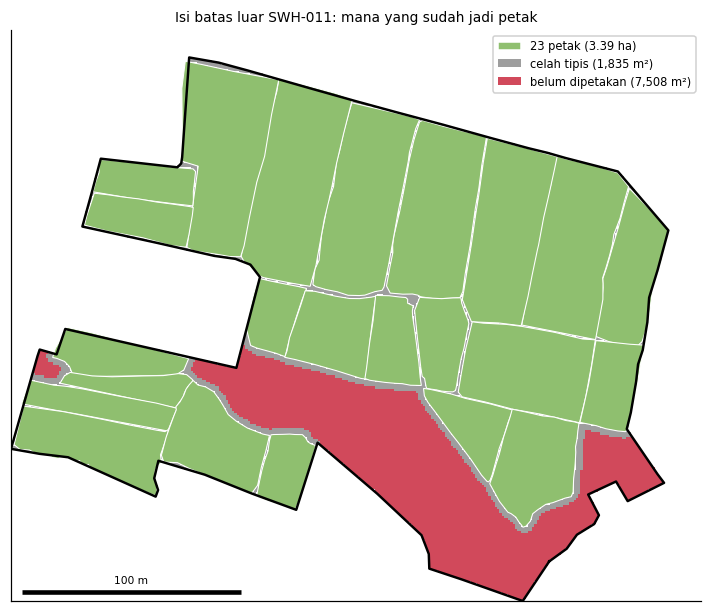

In [26]:
from matplotlib.colors import ListedColormap

LANGKAH_RUANG  = 1.0     # m - kisi penilaian ruang
JARAK_GALENGAN = 3.0     # m - lebih jauh dari ini: bukan galengan

xs_r = np.arange(X.min() + LANGKAH_RUANG/2, X.max(), LANGKAH_RUANG)
ys_r = np.arange(Y.min() + LANGKAH_RUANG/2, Y.max(), LANGKAH_RUANG)
GX, GY = np.meshgrid(xs_r, ys_r)

m_dalam = dalam_poligon(GX.ravel(), GY.ravel(), RING).reshape(GX.shape)
m_petak = np.zeros(GX.shape, bool)
for _pid, _poly in bagian:
    m_petak |= dalam_poligon(GX.ravel(), GY.ravel(), _poly).reshape(GX.shape)
m_kosong = m_dalam & ~m_petak

def lebarkan(mask, radius_m, langkah=LANGKAH_RUANG):
    """Dilasi mask sejauh radius (m) - memisahkan celah tipis dari blok luas."""
    r = int(round(radius_m/langkah)); ny, nx = mask.shape; out = mask.copy()
    for dy in range(-r, r+1):
        for dx in range(-r, r+1):
            if dx*dx + dy*dy > r*r:
                continue
            geser = np.zeros_like(mask)
            ys = slice(max(0, dy), ny + min(0, dy)); yd = slice(max(0, -dy), ny + min(0, -dy))
            xs = slice(max(0, dx), nx + min(0, dx)); xd = slice(max(0, -dx), nx + min(0, -dx))
            geser[yd, xd] = mask[ys, xs]
            out |= geser
    return out

m_dekat = lebarkan(m_petak, JARAK_GALENGAN)
m_belum = m_kosong & ~m_dekat            # jauh dari petak -> blok belum dipetakan
m_tipis = m_kosong & m_dekat             # celah sempit  -> galengan / jalan / saluran

SEL          = LANGKAH_RUANG**2
LUAS_DALAM   = float(m_dalam.sum())*SEL
LUAS_ISI     = float((m_dalam & m_petak).sum())*SEL
LUAS_BELUM   = float(m_belum.sum())*SEL
LUAS_TIPIS   = float(m_tipis.sum())*SEL

print("=" * 66)
print(f"  RUANG DI DALAM BATAS LUAR (kisi {LANGKAH_RUANG:.0f} m, luas cek {LUAS_DALAM:,.0f} m2)")
print("=" * 66)
print(f"  Terisi petak                        : {LUAS_ISI:>9,.0f} m2 "
      f"({100*LUAS_ISI/LUAS_DALAM:>5.1f}%)")
print(f"  Celah tipis (<{JARAK_GALENGAN:.0f} m dari petak)      : {LUAS_TIPIS:>9,.0f} m2 "
      f"({100*LUAS_TIPIS/LUAS_DALAM:>5.1f}%)  <- galengan, jalan, saluran")
print(f"  Blok kosong (>{JARAK_GALENGAN:.0f} m dari petak)      : {LUAS_BELUM:>9,.0f} m2 "
      f"({100*LUAS_BELUM/LUAS_DALAM:>5.1f}%)  <- BELUM DIPETAKAN")
print("-" * 66)
if LUAS_BELUM > 0.05*LUAS_DALAM:
    print(f"  PERHATIAN: {LUAS_BELUM:,.0f} m2 ({100*LUAS_BELUM/LUAS_DALAM:.0f}% batas luar) terlalu lebar")
    print(f"  untuk sekadar galengan. Di peta bawah, daerah merah itu ada di dalam")
    print(f"  batas luar tapi tidak punya poligon petak.")
    print(f"  Artinya:")
    print(f"    - kalau daerah itu memang sawah -> ada petak yang belum digambar,")
    print(f"      dan semua angka air di bawah KURANG sebesar bagian itu;")
    print(f"    - kalau bukan sawah (tegalan, kebun, tanah kosong) -> angka sudah benar,")
    print(f"      dan luas sawah SWH-011 memang {LUAS_PETAK_HA:.2f} ha, bukan {LUAS_HA:.2f} ha.")
    print(f"  Perlu dipastikan di lapangan; notebook ini memakai kemungkinan kedua.")
else:
    print(f"  Sisa luas wajar sebagai galengan/jalan -> luas sawah {LUAS_PETAK_HA:.2f} ha lengkap.")
print("=" * 66)

kat = np.full(m_dalam.shape, np.nan)
kat[m_tipis] = 0.0
kat[m_belum] = 1.0
fig, ax = plt.subplots(figsize=(6.6, 5.6))
ax.imshow(kat, origin="lower", interpolation="nearest",
          extent=[xs_r[0]-LANGKAH_RUANG/2, xs_r[-1]+LANGKAH_RUANG/2,
                  ys_r[0]-LANGKAH_RUANG/2, ys_r[-1]+LANGKAH_RUANG/2],
          cmap=ListedColormap(["#9e9e9e", "#d1495b"]), vmin=-0.5, vmax=1.5, zorder=1)
for _pid, _poly in bagian:
    ax.add_patch(MplPolygon(_poly, closed=True, facecolor="#8fbf6f",
                            edgecolor="white", linewidth=0.7, zorder=2))
ax.plot(np.append(X, X[0]), np.append(Y, Y[0]), color="black", lw=1.6, zorder=3)
ax.plot([X.min()+5, X.min()+105], [Y.min()+4]*2, color="black", lw=3, solid_capstyle="butt")
ax.text(X.min()+55, Y.min()+8, "100 m", ha="center", fontsize=7)
ax.legend(handles=[MplPolygon([(0, 0)], facecolor="#8fbf6f", edgecolor="white",
                              label=f"{N_PETAK} petak ({LUAS_PETAK_HA:.2f} ha)"),
                   MplPolygon([(0, 0)], facecolor="#9e9e9e",
                              label=f"celah tipis ({LUAS_TIPIS:,.0f} m\u00b2)"),
                   MplPolygon([(0, 0)], facecolor="#d1495b",
                              label=f"belum dipetakan ({LUAS_BELUM:,.0f} m\u00b2)")],
          fontsize=7.5, loc="upper right", framealpha=0.9)
ax.set_title("Isi batas luar SWH-011: mana yang sudah jadi petak", fontsize=9)
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
plt.tight_layout(); simpan_gambar(fig, "01_isi_batas_luar"); plt.show()

### Sifat tanah tiap petak

Perkolasi tiap petak dibuat **beragam secara spasial** — bukan satu angka seragam,
juga bukan acak salt-and-pepper. Tanah nyata berubah bertahap: petak bersebelahan
cenderung mirip.

Caranya memakai penjumlahan beberapa gelombang acak (*random Fourier modes*), sehingga
hasilnya bergerombol seperti bercak tanah sungguhan.

Rentang nilainya diambil sama dengan yang **diukur Li et al. (2024)** di lapangan
(4×10⁻⁷ – 1,6×10⁻⁶ per detik), dengan nilai tengah geometriknya sebagai median.

> Ini **tetap tebakan**. Lokasi Li adalah terasering lereng di Jepang; SWH-011 adalah
> sawah dataran. Perkolasi di sini **harus diukur sendiri** — caranya ada di bagian akhir.

In [27]:
A_PERKOLASI_MEDIAN = 8.0e-7     # 1/detik - tengah geometrik rentang Li
SEBARAN_TANAH      = 0.35       # simpangan baku log -> rentang mirip Li
PANJANG_KORELASI   = 70.0       # meter - seberapa lebar bercak tanahnya

def medan_acak_halus(x, y, rng, panjang=70.0, n_mode=14):
    '''Medan acak berkorelasi spasial (jumlah mode Fourier acak), rata-rata 0 ragam 1.'''
    z = np.zeros(len(x))
    for _ in range(n_mode):
        arah = rng.uniform(0, 2*np.pi)
        k    = 2*np.pi / (panjang * rng.uniform(0.7, 1.6))
        fase = rng.uniform(0, 2*np.pi)
        z += np.cos(k*(x*np.cos(arah) + y*np.sin(arah)) + fase)
    return z * math.sqrt(2.0/n_mode)

rng_tanah = np.random.default_rng(SEED + 1)
z = medan_acak_halus(petak["x_m"].to_numpy(), petak["y_m"].to_numpy(),
                     rng_tanah, PANJANG_KORELASI)
petak["a_perkolasi"] = A_PERKOLASI_MEDIAN * np.exp(SEBARAN_TANAH * z)
# I = a*h -> ubah ke (mm/hari per mm genangan)
petak["perk_per_mm"] = petak["a_perkolasi"] * 86_400.0
petak["varietas"] = "Ciherang"

print(f"Koefisien perkolasi a (1/detik):")
print(f"  {petak['a_perkolasi'].min():.2e} .. {petak['a_perkolasi'].max():.2e}"
      f"   median {petak['a_perkolasi'].median():.2e}")
print(f"  Pembanding Li et al. (2024): 4,0e-07 .. 1,6e-06\n")
print(f"Perkolasi pada genangan 20 mm: "
      f"{(petak['perk_per_mm']*20).min():.2f} - {(petak['perk_per_mm']*20).max():.2f} mm/hari")
petak.head(8).round(4)

Koefisien perkolasi a (1/detik):
  4.78e-07 .. 1.45e-06   median 7.85e-07
  Pembanding Li et al. (2024): 4,0e-07 .. 1,6e-06

Perkolasi pada genangan 20 mm: 0.83 - 2.50 mm/hari


,urutan,id_petak,simpul,luas_m2,keliling_m,panjang_m,lebar_m,x_m,y_m,luas_ha,a_perkolasi,perk_per_mm,varietas
0,1,PTK-01,17,1426.0645,171.4378,70.5646,45.7104,117.4704,35.8619,0.1426,0.0,0.0987,Ciherang
1,2,PTK-02,23,2627.3900,222.8836,86.0608,61.1929,91.3718,47.6569,0.2627,0.0,0.0498,Ciherang
2,3,PTK-03,20,2467.0192,220.3096,87.0270,53.8886,60.5045,55.3510,0.2467,0.0,0.0557,Ciherang
3,4,PTK-04,31,2624.4568,218.7492,82.6778,56.6285,28.5900,63.8838,0.2624,0.0,0.0678,Ciherang
4,5,PTK-05,36,2703.5122,229.9583,87.2108,63.1322,-4.3899,69.2745,0.2704,0.0,0.0413,Ciherang
5,6,PTK-06,22,3029.7854,241.5087,95.4978,65.7977,-36.3374,77.8565,0.3030,0.0,0.0644,Ciherang
6,7,PTK-07,19,2841.4680,242.3986,92.2159,53.7780,-68.5794,92.0125,0.2841,0.0,0.0918,Ciherang
7,8,PTK-08,15,727.1039,121.7244,47.6280,26.3754,-104.1949,78.1364,0.0727,0.0,0.0619,Ciherang


### Peta dasar dari citra satelit

In [28]:
TILE_URL = ("https://server.arcgisonline.com/ArcGIS/rest/services/"
            "World_Imagery/MapServer/tile/{z}/{y}/{x}")
KREDIT   = "Citra: Esri, Maxar, Earthstar Geographics"
ZOOM, MAX_TILE = 18, 64

def lonlat_ke_piksel(lo, la, z):
    n = 256 * 2**z
    return ((lo+180.0)/360.0*n,
            (1.0 - math.asinh(math.tan(math.radians(la)))/math.pi)/2.0*n)

def piksel_ke_lonlat(px, py, z):
    n = 256 * 2**z
    return (px/n*360.0 - 180.0,
            math.degrees(math.atan(math.sinh(math.pi*(1.0 - 2.0*py/n)))))

def ambil_tile(z, x, y, timeout=20):
    f = TILE_DIR / f"{z}_{x}_{y}.jpg"
    if f.exists():
        return mpimg.imread(f)
    req = urllib.request.Request(TILE_URL.format(z=z, x=x, y=y), headers={
        "User-Agent": "WMS-AgrinIrigation/1.0 (notebook riset lokal)"})
    with urllib.request.urlopen(req, timeout=timeout) as r:
        d = r.read()
    f.write_bytes(d)
    return mpimg.imread(_io.BytesIO(d), format="jpeg")

def susun_basemap(lon, lat, z=ZOOM, margin=0.15):
    dlo = (lon.max()-lon.min())*margin; dla = (lat.max()-lat.min())*margin
    px0, py0 = lonlat_ke_piksel(lon.min()-dlo, lat.max()+dla, z)
    px1, py1 = lonlat_ke_piksel(lon.max()+dlo, lat.min()-dla, z)
    tx0, ty0, tx1, ty1 = int(px0//256), int(py0//256), int(px1//256), int(py1//256)
    n_tile = (tx1-tx0+1)*(ty1-ty0+1)
    if n_tile > MAX_TILE:
        raise RuntimeError(f"butuh {n_tile} tile (batas {MAX_TILE})")
    kanvas = np.zeros(((ty1-ty0+1)*256, (tx1-tx0+1)*256, 3), dtype=np.uint8)
    for ty in range(ty0, ty1+1):
        for tx in range(tx0, tx1+1):
            im = ambil_tile(z, tx, ty)
            if im.dtype != np.uint8:
                im = (np.clip(im, 0, 1)*255).astype(np.uint8)
            kanvas[(ty-ty0)*256:(ty-ty0+1)*256,
                   (tx-tx0)*256:(tx-tx0+1)*256] = im[:, :, :3]
    lk, la_ = piksel_ke_lonlat(tx0*256, ty0*256, z)
    lka, lb = piksel_ke_lonlat((tx1+1)*256, (ty1+1)*256, z)
    return kanvas, [(lk-lon0)*M_PER_DEG_LON, (lka-lon0)*M_PER_DEG_LON,
                    (lb-lat0)*M_PER_DEG_LAT, (la_-lat0)*M_PER_DEG_LAT], n_tile

BASEMAP = EXTENT = None
try:
    socket.setdefaulttimeout(25)
    BASEMAP, EXTENT, n_tile = susun_basemap(lon, lat)
    print(f"Basemap siap: {BASEMAP.shape[1]}x{BASEMAP.shape[0]} piksel dari {n_tile} tile")
    print(f"Skala: {40075016.686*math.cos(phi)/2**ZOOM/256:.2f} m/piksel | {KREDIT}")
except Exception as e:
    print(f"Basemap tidak tersedia ({type(e).__name__}: {e}) - peta tetap digambar tanpa citra.")

Basemap siap: 1024x768 piksel dari 12 tile
Skala: 0.59 m/piksel | Citra: Esri, Maxar, Earthstar Geographics


[gambar] 02_petak_luas_perkolasi.png      1,040 KB


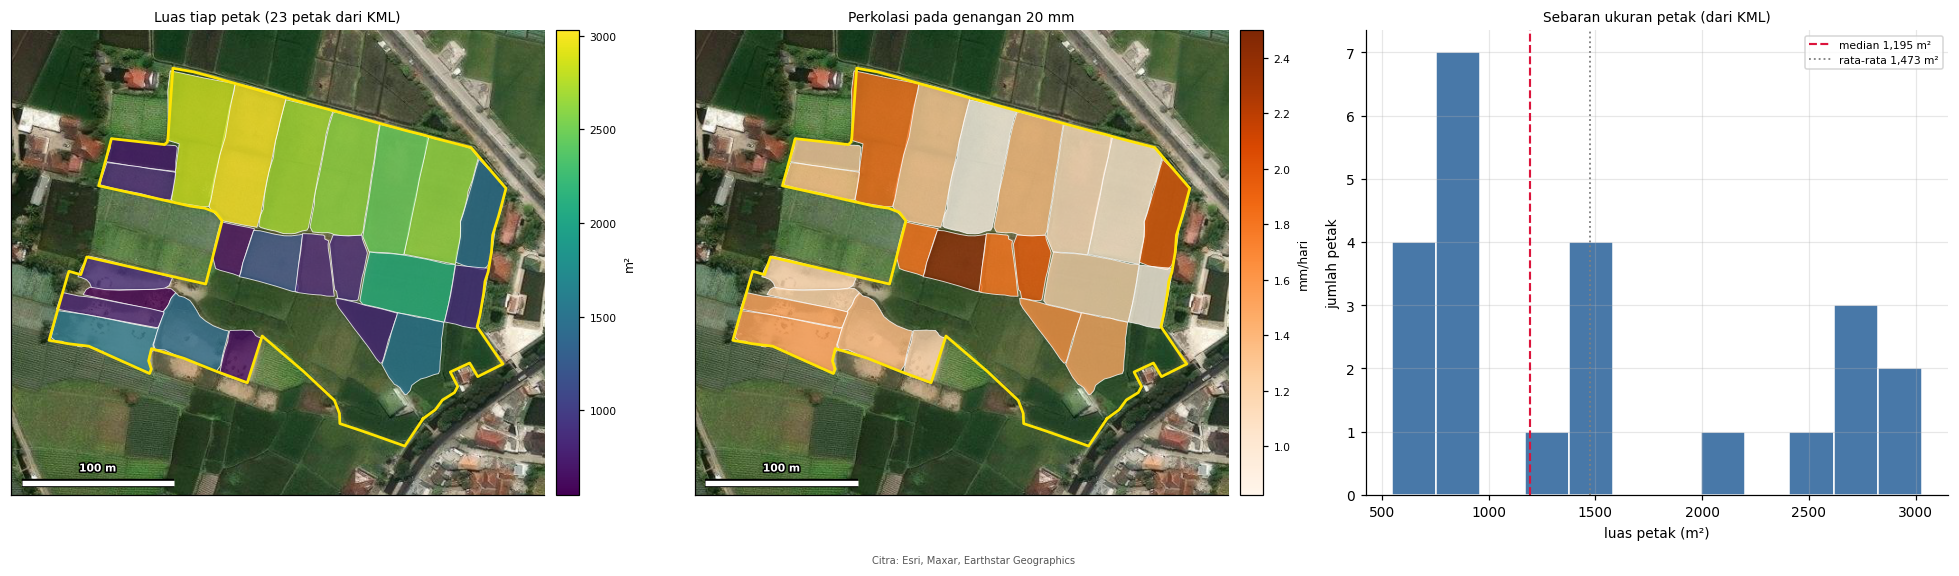

In [29]:
ASPEK_PETA = ((X.max()+25) - (X.min()-25)) / ((Y.max()+25) - (Y.min()-32))

def ukuran_peta(n_kolom, lebar_total=18.0, porsi_peta=0.82, ruang_judul=0.9):
    return (lebar_total, porsi_peta*lebar_total/n_kolom/ASPEK_PETA + ruang_judul)

def batang_skala(ax, panjang_m=100):
    x0, y0 = X.min()-18, Y.min()-24
    ax.plot([x0, x0+panjang_m], [y0, y0], color="white", lw=3.5, solid_capstyle="butt",
            path_effects=[pe.withStroke(linewidth=5.5, foreground="black")], zorder=8)
    ax.text(x0+panjang_m/2, y0+6, f"{panjang_m} m", ha="center", va="bottom", fontsize=7,
            color="white", weight="bold", zorder=8,
            path_effects=[pe.withStroke(linewidth=2, foreground="black")])

def peta_petak(nilai, judul, satuan, cmap="YlOrRd", fmt="{:.0f}", ax=None,
               tampil_angka=False, vmin=None, vmax=None):
    '''Petak diwarnai menurut `nilai` (Series ber-index id_petak) di atas citra.'''
    if ax is None:
        _, ax = plt.subplots(figsize=(7.4, 6.2))
    if BASEMAP is not None:
        ax.imshow(BASEMAP, extent=EXTENT, origin="upper", interpolation="bilinear", zorder=0)
    else:
        ax.set_facecolor("#e8e8e8")
    v = np.array([float(nilai[p]) for p in petak["id_petak"]])
    norm = plt.Normalize(v.min() if vmin is None else vmin,
                         v.max() if vmax is None else vmax)
    cm = plt.get_cmap(cmap)
    warna_petak = dict(zip(petak["id_petak"], v))
    for pid, poly in bagian:              # satu petak = satu poligon dari KML
        val = warna_petak[pid]
        ax.add_patch(MplPolygon(poly, closed=True, facecolor=cm(norm(val)),
                                edgecolor="white", linewidth=0.6, alpha=0.78, zorder=2))
        if tampil_angka:
            cx, cy = pusat_poligon(poly)
            ax.text(cx, cy, fmt.format(val), ha="center", va="center", fontsize=4.6,
                    color="white", weight="bold", zorder=4,
                    path_effects=[pe.withStroke(linewidth=1.2, foreground="black")])
    ax.plot(Xc, Yc, color="#ffe400", lw=1.8, zorder=5)
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cm); sm.set_array([])
    cb = plt.colorbar(sm, ax=ax, fraction=0.043, pad=0.02)
    cb.set_label(satuan, fontsize=8); cb.ax.tick_params(labelsize=7)
    batang_skala(ax)
    ax.set_xlim(X.min()-25, X.max()+25); ax.set_ylim(Y.min()-32, Y.max()+25)
    ax.set_aspect("equal"); ax.set_title(judul, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    return ax

fig, axes = plt.subplots(1, 3, figsize=ukuran_peta(3, 18.0))
peta_petak(petak.set_index("id_petak")["luas_m2"], f"Luas tiap petak ({N_PETAK} petak dari KML)",
           "m²", cmap="viridis", ax=axes[0])
peta_petak(petak.set_index("id_petak")["perk_per_mm"]*20,
           "Perkolasi pada genangan 20 mm", "mm/hari", cmap="Oranges", ax=axes[1])
ax = axes[2]
ax.hist(petak["luas_m2"], bins=12, color="#4878a8", edgecolor="white")
ax.axvline(petak["luas_m2"].median(), color="crimson", ls="--", lw=1.4,
           label=f"median {petak['luas_m2'].median():,.0f} m²")
ax.axvline(petak["luas_m2"].mean(), color="grey", ls=":", lw=1.2,
           label=f"rata-rata {petak['luas_m2'].mean():,.0f} m²")
ax.set_xlabel("luas petak (m²)"); ax.set_ylabel("jumlah petak")
ax.set_title("Sebaran ukuran petak (dari KML)", fontsize=9); ax.legend(fontsize=7)
ax.set_aspect("auto")
fig.text(0.5, 0.005, KREDIT if BASEMAP is not None else "(tanpa citra satelit)",
         ha="center", fontsize=6.5, color="#555")
plt.tight_layout(rect=[0, 0.02, 1, 1])
simpan_gambar(fig, "02_petak_luas_perkolasi"); plt.show()

---
## 4. Cuaca, ETo, dan Kc

**ETo** = patokan penguapan dari cuaca saja (seolah lahan ditanami rumput standar).
Rumus Hargreaves berbasis radiasi, persis pers. (1) paper Arif:

$$ ET_o = 0{,}0135\,(T_{rata}+17{,}78)\;R_s\left(\frac{238{,}8}{595{,}5-0{,}55\,T_{rata}}\right) $$

**Kc** = pengali dari rumput ke padi. **ETc = Kc × ETo**. Nilai Kc diambil dari Tabel 1
Arif (hasil ukur di sawah Indonesia), bukan tabel FAO.

| Fase | Kc genangan (FL) | Kc SRI |
|---|---|---|
| Awal | 1,01 | 1,00 |
| Pertumbuhan | 1,02 | 0,96 |
| Reproduktif | 1,09 | 1,02 |
| Pemasakan | 1,05 | 1,04 |

In [30]:
rng = np.random.default_rng(SEED)
hari = np.arange(N_HARI); maju = hari/(N_HARI-1)
tanggal = [TANGGAL_TANAM + timedelta(days=int(d)) for d in hari]

t_maks = 29.0 + 4.0*maju + rng.normal(0, 1.0, N_HARI)
t_min  = 18.0 + 2.0*maju + rng.normal(0, 0.8, N_HARI)
t_rata = (t_maks + t_min)/2.0
rs     = np.clip(15.0 + 9.0*maju + rng.normal(0, 2.2, N_HARI), 5.0, 30.0)

# hujan: rantai Markov + campuran ringan/lebat (ekor berat seperti hujan tropis)
hujan, basah = np.zeros(N_HARI), False
for i in range(N_HARI):
    amb = (0.45 if basah else 0.15) * (1.0 - 0.5*maju[i])
    basah = rng.random() < amb
    if basah:
        hujan[i] = rng.exponential(32.0 if rng.random() < 0.15 else 6.0)
hujan = np.round(hujan, 1); rs[hujan > 0] *= 0.75

def hitung_eto(t, r):
    '''ETo (mm/hari) - Hargreaves berbasis radiasi, Arif pers. (1).'''
    t = np.asarray(t, float); r = np.asarray(r, float)
    return 0.0135*(t + 17.78)*r*(238.8/(595.5 - 0.55*t))

FASE = [("awal", 20), ("pertumbuhan", 30), ("reproduktif", 40), ("pemasakan", 20)]
assert sum(d for _, d in FASE) == N_HARI
KC = {"FL":  {"awal": 1.01, "pertumbuhan": 1.02, "reproduktif": 1.09, "pemasakan": 1.05},
      "SRI": {"awal": 1.00, "pertumbuhan": 0.96, "reproduktif": 1.02, "pemasakan": 1.04}}
ATURAN_TMA = {   # (target, pemicu, tinggi lubang buang) dalam mm
    "FL":  {"awal": (20, 10, 50), "pertumbuhan": (20, 10, 50),
            "reproduktif": (10, 5, 40), "pemasakan": (10, 0, 40)},
    "SRI": {"awal": (10, 0, 40), "pertumbuhan": (10, -20, 40),
            "reproduktif": (5, -25, 30), "pemasakan": (0, -30, 30)}}

fase_harian = np.concatenate([[nm]*d for nm, d in FASE])
cuaca = pd.DataFrame({"hari": hari+1, "tanggal": tanggal, "fase": fase_harian,
                      "t_maks": t_maks.round(2), "t_min": t_min.round(2),
                      "t_rata": t_rata.round(2), "rs_mj": rs.round(2), "hujan_mm": hujan})
cuaca["eto_mm"] = hitung_eto(cuaca["t_rata"], cuaca["rs_mj"]).round(3)
for rez in ("FL", "SRI"):
    cuaca[f"kc_{rez}"]  = [KC[rez][f] for f in fase_harian]
    cuaca[f"etc_{rez}"] = (cuaca[f"kc_{rez}"]*cuaca["eto_mm"]).round(3)

print(f"Musim tanam : {tanggal[0]} s/d {tanggal[-1]} ({N_HARI} hari)")
print(f"Hujan       : {hujan.sum():.0f} mm dalam {(hujan>0).sum()} hari "
      f"(terbesar {hujan.max():.0f} mm/hari)")
print(f"ETo         : rata {cuaca['eto_mm'].mean():.2f} mm/hari "
      f"({cuaca['eto_mm'].min():.2f} - {cuaca['eto_mm'].max():.2f})")
print(f"ETc total   : FL {cuaca['etc_FL'].sum():.0f} mm | SRI {cuaca['etc_SRI'].sum():.0f} mm")
print(f"\nUji rumus ETo terhadap paper Arif:")
for t, r, target in [(25.0, 15.0, 3.5), (25.0, 25.0, 6.0)]:
    print(f"  T={t}C Rs={r} MJ -> {float(hitung_eto(t, r)):.2f} mm/hari (paper ~{target})")

Musim tanam : 2026-05-15 s/d 2026-09-01 (110 hari)
Hujan       : 216 mm dalam 19 hari (terbesar 58 mm/hari)
ETo         : rata 4.41 mm/hari (2.23 - 6.69)
ETc total   : FL 511 mm | SRI 488 mm

Uji rumus ETo terhadap paper Arif:
  T=25.0C Rs=15.0 MJ -> 3.56 mm/hari (paper ~3.5)
  T=25.0C Rs=25.0 MJ -> 5.93 mm/hari (paper ~6.0)


---
## 5. Neraca air per petak

Tiap hari, untuk tiap petak:

$$ h_{besok} = h_{hari\,ini} + \underbrace{Hujan + Irigasi}_{masuk} - \underbrace{ET_c - Perkolasi - Limpasan}_{keluar} $$

| Komponen | Aturan | Sumber |
|---|---|---|
| ETc | `Kc × ETo` | Arif |
| Perkolasi | `a·h·86400` saat tergenang; saat kering tetap jalan `60%` dari laju penuh | Li pers. (9) |
| Limpasan | kelebihan di atas lubang buang langsung keluar | Li pers. (7) |
| Irigasi | kalau `h < pemicu` → isi sampai `target` | aturan kontrol WMS |

In [31]:
def simulasi_petak(cuaca, rezim, perk_per_mm, h_awal=20.0, aturan=None, rasio_kering=None):
    '''Neraca air harian satu petak. Semua satuan mm.'''
    aturan = ATURAN_TMA if aturan is None else aturan
    rasio_kering = PERK_KERING_RASIO if rasio_kering is None else rasio_kering
    n = len(cuaca); h = float(h_awal)
    kol = {k: np.zeros(n) for k in ("tma", "irigasi", "etc", "perkolasi", "limpasan", "hujan_mm")}
    etc_all = cuaca[f"etc_{rezim}"].to_numpy()
    for i in range(n):
        target, pemicu, hd = aturan[rezim][cuaca["fase"].iat[i]]
        hj = float(cuaca["hujan_mm"].iat[i]); h += hj
        irig = 0.0
        if h < pemicu:
            irig = target - h; h = float(target)
        etc  = float(etc_all[i])
        perk = perk_per_mm*h if h > 0 else perk_per_mm*hd*rasio_kering
        h -= (etc + perk)
        limp = 0.0
        if h > hd:
            limp = h - hd; h = float(hd)
        h = max(h, -150.0)
        for k, v in zip(kol, (h, irig, etc, perk, limp, hj)):
            kol[k][i] = v
    out = pd.DataFrame(kol)
    out.insert(0, "hari", cuaca["hari"].to_numpy())
    out.insert(1, "fase", cuaca["fase"].to_numpy())
    return out

harian, ringkas = [], []
for _, p in petak.iterrows():
    for rezim in ("FL", "SRI"):
        sim = simulasi_petak(cuaca, rezim, p["perk_per_mm"])
        sim.insert(0, "rezim", rezim); sim.insert(0, "id_petak", p["id_petak"])
        harian.append(sim)
        mm2m3 = p["luas_m2"]/1000.0
        ringkas.append({
            "id_petak": p["id_petak"], "rezim": rezim,
            "luas_m2": p["luas_m2"], "luas_ha": p["luas_ha"],
            "perk_per_mm": p["perk_per_mm"],
            "hujan_mm": sim["hujan_mm"].sum(), "irigasi_mm": sim["irigasi"].sum(),
            "etc_mm": sim["etc"].sum(), "perkolasi_mm": sim["perkolasi"].sum(),
            "limpasan_mm": sim["limpasan"].sum(),
            "irigasi_m3": sim["irigasi"].sum()*mm2m3, "etc_m3": sim["etc"].sum()*mm2m3,
            "perkolasi_m3": sim["perkolasi"].sum()*mm2m3,
            "limpasan_m3": sim["limpasan"].sum()*mm2m3,
            "tma_rata": sim["tma"].mean(), "tma_min": sim["tma"].min(),
            "hari_diairi": int((sim["irigasi"] > 0).sum()),
            "hari_kering": int((sim["tma"] < 0).sum())})
harian   = pd.concat(harian, ignore_index=True)
ringkasan = pd.DataFrame(ringkas)

# cek penutupan neraca
cek = ringkasan.copy()
cek["sisa"] = (cek["hujan_mm"] + cek["irigasi_mm"]
               - cek["etc_mm"] - cek["perkolasi_mm"] - cek["limpasan_mm"]
               - harian.groupby(["id_petak","rezim"])["tma"].last().reset_index(drop=True).to_numpy()
               + 20.0)
print(f"Simulasi: {N_PETAK} petak x 2 rezim x {N_HARI} hari = {len(harian):,} baris")
print(f"Galat penutupan neraca terbesar: {cek['sisa'].abs().max():.6f} mm "
      f"-> {'NERACA TERTUTUP' if cek['sisa'].abs().max() < 1e-6 else 'PERIKSA'}")

Simulasi: 23 petak x 2 rezim x 110 hari = 5,060 baris
Galat penutupan neraca terbesar: 0.000000 mm -> NERACA TERTUTUP


---
## 6. Kebutuhan air per petak  ← pertanyaan 1

Dua satuan yang **berbeda artinya**:

- **mm** = seberapa haus per satuan luas. Tidak terpengaruh besar-kecilnya petak.
- **m³** = jumlah air sebenarnya. Petak besar otomatis butuh lebih banyak.

In [32]:
fl  = ringkasan[ringkasan.rezim == "FL" ].set_index("id_petak")
sri = ringkasan[ringkasan.rezim == "SRI"].set_index("id_petak")

print("=" * 74)
print(f"          KEBUTUHAN AIR — {N_PETAK} PETAK, {LUAS_PETAK_HA:.2f} ha")
print("=" * 74)
for nm, d in [("FL (genangan)", fl), ("SRI (basah-kering)", sri)]:
    mm_ttb = d["irigasi_m3"].sum()/(LUAS_PETAK_M2/1000)   # rata-rata tertimbang luas petak
    print(f"\n  {nm}")
    print(f"    Per petak (mm)  : {d['irigasi_mm'].min():6.0f} - {d['irigasi_mm'].max():6.0f}"
          f"   median {d['irigasi_mm'].median():6.0f}")
    print(f"    Per petak (m3)  : {d['irigasi_m3'].min():6.1f} - {d['irigasi_m3'].max():6.1f}"
          f"   median {d['irigasi_m3'].median():6.1f}")
    print(f"    SELURUH PETAK   : {mm_ttb:,.0f} mm = {d['irigasi_m3'].sum():,.0f} m3")
    print(f"    Hari perlu diairi: {d['hari_diairi'].mean():.0f} dari {N_HARI} hari")
print("\n" + "-"*74)
print(f"  Pembanding paper Arif (Wonogiri): FL 536 mm, SRI 518 mm per musim")
print("=" * 74)

print(f"\n10 petak paling BOROS (FL, mm):")
print(fl.nlargest(10, "irigasi_mm")[["luas_m2","perk_per_mm","irigasi_mm","irigasi_m3"]]
      .to_string(float_format=lambda v: f"{v:,.2f}"))

          KEBUTUHAN AIR — 23 PETAK, 3.39 ha

  FL (genangan)
    Per petak (mm)  :    390 -    509   median    426
    Per petak (m3)  :  226.2 - 1290.2   median  608.4
    SELURUH PETAK   : 427 mm = 14,468 m3
    Hari perlu diairi: 50 dari 110 hari

  SRI (basah-kering)
    Per petak (mm)  :    339 -    488   median    407
    Per petak (m3)  :  205.5 - 1275.4   median  582.5
    SELURUH PETAK   : 404 mm = 13,686 m3
    Hari perlu diairi: 13 dari 110 hari

--------------------------------------------------------------------------
  Pembanding paper Arif (Wonogiri): FL 536 mm, SRI 518 mm per musim

10 petak paling BOROS (FL, mm):
          luas_m2  perk_per_mm  irigasi_mm  irigasi_m3
id_petak                                              
PTK-17   1,194.58         0.12      509.28      608.38
PTK-19     841.60         0.10      473.78      398.73
PTK-01   1,426.06         0.10      462.01      658.85
PTK-16     654.91         0.09      454.14      297.42
PTK-07   2,841.47         0.09  

[gambar] 03_kebutuhan_air.png             1,016 KB


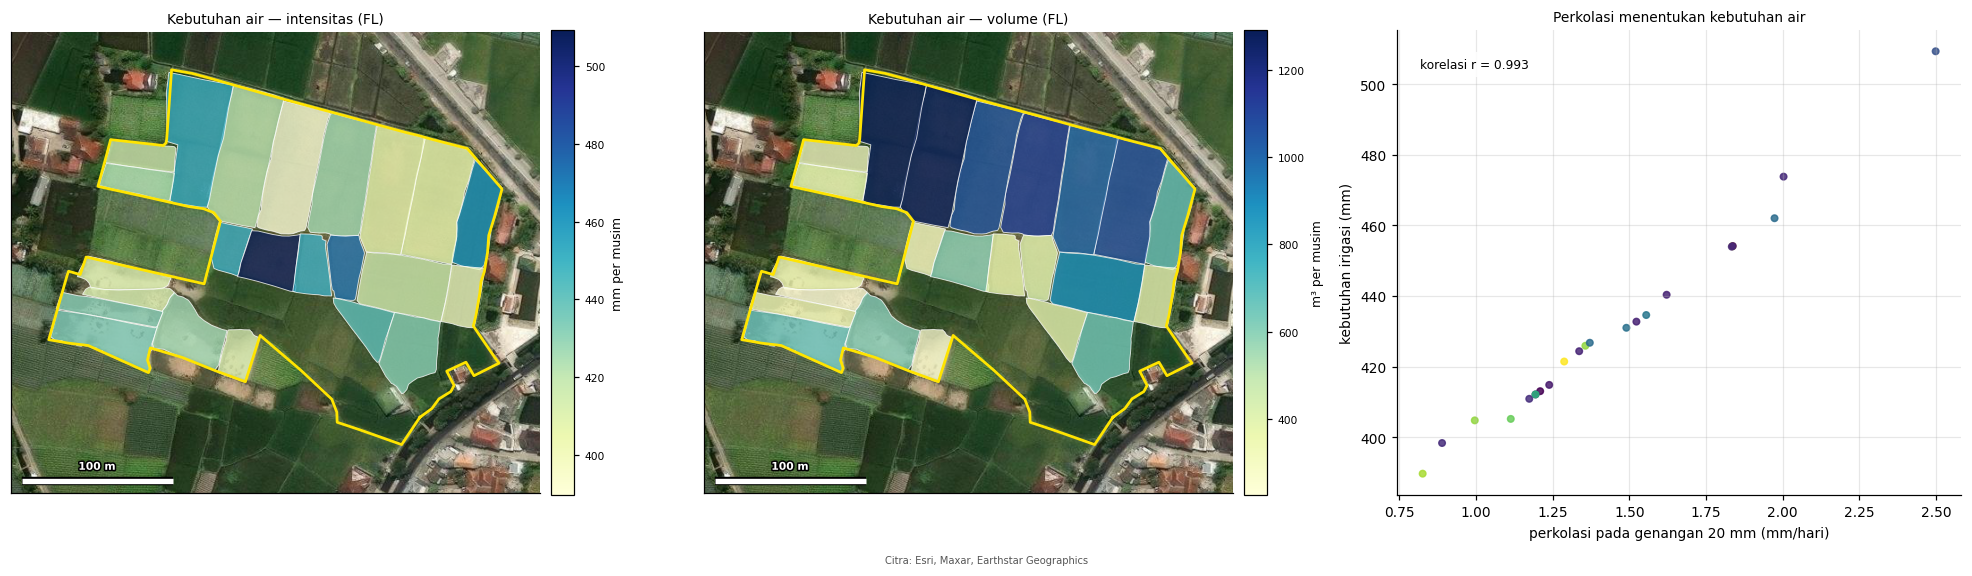

Korelasi perkolasi vs kebutuhan irigasi: r = 0.993
Peta mm dan peta m3 BEDA POLANYA: mm mengikuti tanah, m3 mengikuti luas petak.


In [33]:
fig, axes = plt.subplots(1, 3, figsize=ukuran_peta(3, 18.0))
peta_petak(fl["irigasi_mm"], "Kebutuhan air — intensitas (FL)", "mm per musim",
           cmap="YlGnBu", ax=axes[0])
peta_petak(fl["irigasi_m3"], "Kebutuhan air — volume (FL)", "m³ per musim",
           cmap="YlGnBu", ax=axes[1])
ax = axes[2]
ax.scatter(fl["perk_per_mm"]*20, fl["irigasi_mm"], s=18, c=fl["luas_m2"],
           cmap="viridis", alpha=0.85)
ax.set_xlabel("perkolasi pada genangan 20 mm (mm/hari)")
ax.set_ylabel("kebutuhan irigasi (mm)")
ax.set_title("Perkolasi menentukan kebutuhan air", fontsize=9); ax.set_aspect("auto")
korelasi = np.corrcoef(fl["perk_per_mm"], fl["irigasi_mm"])[0, 1]
ax.text(0.04, 0.94, f"korelasi r = {korelasi:.3f}", transform=ax.transAxes, fontsize=8,
        va="top", bbox=dict(fc="white", alpha=0.85, ec="none"))
fig.text(0.5, 0.005, KREDIT if BASEMAP is not None else "(tanpa citra satelit)",
         ha="center", fontsize=6.5, color="#555")
plt.tight_layout(rect=[0, 0.02, 1, 1])
simpan_gambar(fig, "03_kebutuhan_air"); plt.show()

print(f"Korelasi perkolasi vs kebutuhan irigasi: r = {korelasi:.3f}")
print("Peta mm dan peta m3 BEDA POLANYA: mm mengikuti tanah, m3 mengikuti luas petak.")

---
## 7. Debit untuk mengairi  ← pertanyaan 2

Tiga angka debit yang berbeda dan sering tertukar:

| Istilah | Artinya | Untuk apa |
|---|---|---|
| **NFR** | kebutuhan bersih **di petak** (mm/hari) | dasar hitungan |
| **DR** | yang harus diambil **di bendung** (l/detik/ha) | perencanaan jangka panjang |
| **Debit pengisian** | debit **sesaat** saat mengisi petak | menentukan ukuran fisik pintu |

$$ DR = \frac{NFR}{8{,}64 \times e} $$

Angka **8,64** cuma konversi satuan: 1 mm/hari di 1 ha = 10.000 L / 86.400 detik
= 0,1157 l/detik, dan 1 ÷ 0,1157 = 8,64. `e` = efisiensi irigasi (KP-01: 0,90 × 0,90 × 0,80 ≈ 0,65).

In [34]:
def ke_l_detik_ha(nfr_mm_hari, efisiensi=EFISIENSI_IRIGASI):
    return nfr_mm_hari / (8.64 * efisiensi)

def kebutuhan_penyiapan_lahan(eto, perkolasi, S=250.0, T=30.0):
    '''IR (mm/hari) - van de Goor & Zijlstra, KP-01.'''
    M = 1.1*eto + perkolasi
    k = M*T/S
    return M*math.exp(k)/(math.exp(k) - 1.0)

deb = fl.copy()
deb["nfr_mm_hari"]   = deb["irigasi_mm"]/N_HARI
deb["dr_l_detik_ha"] = ke_l_detik_ha(deb["nfr_mm_hari"])
deb["debit_l_detik"] = deb["dr_l_detik_ha"]*deb["luas_ha"]

eto_awal = float(cuaca["eto_mm"][:30].mean())
deb["perk_pl_mm_hari"] = deb["perk_per_mm"]*50.0        # genangan 5 cm saat penyiapan
deb["IR_mm_hari"]      = [kebutuhan_penyiapan_lahan(eto_awal, p) for p in deb["perk_pl_mm_hari"]]
deb["dr_pl_l_detik_ha"] = ke_l_detik_ha(deb["IR_mm_hari"])
deb["debit_pl_l_detik"] = deb["dr_pl_l_detik_ha"]*deb["luas_ha"]

nfr_lahan = deb["irigasi_m3"].sum()/(LUAS_PETAK_M2/1000)/N_HARI
print("=" * 70)
print(f"          DEBIT — {N_PETAK} PETAK, {LUAS_PETAK_HA:.2f} ha")
print("=" * 70)
print(f"\n  A. FASE TUMBUH (rata-rata semusim)")
print(f"     NFR             : {nfr_lahan:8.2f} mm/hari")
print(f"     DR              : {ke_l_detik_ha(nfr_lahan):8.3f} l/detik/ha")
print(f"     Debit total     : {ke_l_detik_ha(nfr_lahan)*LUAS_PETAK_HA:8.2f} l/detik "
      f"= {ke_l_detik_ha(nfr_lahan)*LUAS_PETAK_HA/1000:.4f} m3/detik")
print(f"     Per petak       : {deb['debit_l_detik'].min():.3f} - "
      f"{deb['debit_l_detik'].max():.3f} l/detik")
print(f"\n  B. PENYIAPAN LAHAN (van de Goor & Zijlstra, S=250 mm, T=30 hari)")
print(f"     IR              : {deb['IR_mm_hari'].min():.1f} - {deb['IR_mm_hari'].max():.1f} mm/hari")
print(f"     DR puncak       : {deb['dr_pl_l_detik_ha'].max():8.3f} l/detik/ha")
print(f"     Debit total     : {deb['debit_pl_l_detik'].sum():8.2f} l/detik")
print(f"     -> {deb['debit_pl_l_detik'].sum()/(ke_l_detik_ha(nfr_lahan)*LUAS_PETAK_HA):.1f}x "
      f"lebih besar dari fase tumbuh")
print(f"\n  SALURAN DIRANCANG UNTUK ANGKA B, BUKAN A.")
print("=" * 70)

          DEBIT — 23 PETAK, 3.39 ha

  A. FASE TUMBUH (rata-rata semusim)
     NFR             :     3.88 mm/hari
     DR              :    0.691 l/detik/ha
     Debit total     :     2.34 l/detik = 0.0023 m3/detik
     Per petak       : 0.037 - 0.209 l/detik

  B. PENYIAPAN LAHAN (van de Goor & Zijlstra, S=250 mm, T=30 hari)
     IR              : 11.6 - 14.4 mm/hari
     DR puncak       :    2.558 l/detik/ha
     Debit total     :     7.56 l/detik
     -> 3.2x lebih besar dari fase tumbuh

  SALURAN DIRANCANG UNTUK ANGKA B, BUKAN A.


### Debit saat mengisi petak — yang menentukan ukuran pintu

Kalau satu petak mau diisi sampai tergenang dalam sekian jam, berapa debit yang harus masuk?

Air pengisian awal terdiri dari **penjenuhan tanah** + **lapisan genangan** + kehilangan
selama mengisi. Dari debitnya bisa dihitung **diameter pintu** lewat persamaan orifice
Li pers. (4) yang dibalik:

$$ d = \sqrt{\frac{4}{\pi}\cdot\frac{Q}{C_d\sqrt{2gH}}} $$

In [35]:
ZONA_AKAR_MM, THETA_JENUH, THETA_AWAL = 300.0, 0.50, 0.30
PENJENUHAN_MM = (THETA_JENUH - THETA_AWAL)*ZONA_AKAR_MM

def diameter_orifice(Q_m3s, tinggi_tekan_m=0.010, Cd=0.62):
    '''Diameter lubang pintu (m) untuk debit Q - Li pers. (4) dibalik.'''
    if Q_m3s <= 0: return 0.0
    return math.sqrt(4.0*(Q_m3s/(Cd*math.sqrt(2*9.81*tinggi_tekan_m)))/math.pi)

target_gen = ATURAN_TMA["FL"]["awal"][0]
deb["isi_mm"] = (PENJENUHAN_MM + target_gen
                 + (deb["perk_per_mm"]*target_gen + 1.1*eto_awal)*(LAMA_ISI_JAM/24.0))
deb["isi_m3"] = deb["isi_mm"]*deb["luas_m2"]/1000.0
deb["Q_isi_l_detik"] = deb["isi_m3"]/(LAMA_ISI_JAM*3600.0)*1000
deb["diameter_cm"]   = [diameter_orifice(q/1000)*100 for q in deb["Q_isi_l_detik"]]

print(f"Penjenuhan tanah : {PENJENUHAN_MM:.0f} mm  (({THETA_JENUH}-{THETA_AWAL}) x {ZONA_AKAR_MM:.0f} mm)")
print(f"Lapisan genangan : {target_gen} mm")
print(f"Total pengisian  : {deb['isi_mm'].min():.0f} - {deb['isi_mm'].max():.0f} mm "
      f"= {deb['isi_m3'].sum():,.0f} m3 untuk seluruh petak")
print(f"  -> {100*deb['isi_m3'].sum()/deb['irigasi_m3'].sum():.1f}% dari irigasi semusim,"
      f" tapi dibutuhkan SEKALIGUS di awal\n")

print("DEBIT PENGISIAN SELURUH PETAK menurut target lama pengisian")
print("=" * 68)
print(f"{'lama isi':>10}{'debit total':>16}{'per hektar':>16}{'vs fase tumbuh':>18}")
print("-" * 68)
dr_tumbuh = ke_l_detik_ha(nfr_lahan)
for jam in (3, 6, 12, 24):
    tot = deb["isi_m3"].sum()/(jam*3600)*1000
    print(f"{jam:>8} jam{tot:>13,.1f} l/dt{tot/LUAS_PETAK_HA:>12,.1f} l/dt/ha"
          f"{tot/LUAS_PETAK_HA/dr_tumbuh:>15,.0f}x")
print("-" * 68)
print(f"{'fase tumbuh':>10}{dr_tumbuh*LUAS_PETAK_HA:>13,.2f} l/dt{dr_tumbuh:>12,.2f} l/dt/ha{1:>15}x")

print(f"\nDiameter pintu untuk pengisian {LAMA_ISI_JAM:.0f} jam: "
      f"{deb['diameter_cm'].min():.0f} - {deb['diameter_cm'].max():.0f} cm")
KAP = 50.0
g = deb.sort_values("Q_isi_l_detik"); kum = 0.0; n_muat = 0
for q in g["Q_isi_l_detik"]:
    if kum + q > KAP: break
    kum += q; n_muat += 1
n_gil = math.ceil(deb["Q_isi_l_detik"].sum()/KAP)
print(f"\nKalau saluran hanya sanggup {KAP:.0f} l/detik:")
print(f"  satu giliran {LAMA_ISI_JAM:.0f} jam memuat {n_muat} dari {N_PETAK} petak")
print(f"  mengisi semua {N_PETAK} petak perlu {n_gil} giliran "
      f"= {n_gil*LAMA_ISI_JAM:.0f} jam ({n_gil*LAMA_ISI_JAM/24:.1f} hari)")
print(f"\n-> Mengisi semua petak serentak TIDAK MUNGKIN secara hidraulik.")
print(f"   Giliran air itu keharusan fisika, bukan sekadar kebiasaan.")

Penjenuhan tanah : 60 mm  ((0.5-0.3) x 300 mm)
Lapisan genangan : 20 mm
Total pengisian  : 81 - 82 mm = 2,754 m3 untuk seluruh petak
  -> 19.0% dari irigasi semusim, tapi dibutuhkan SEKALIGUS di awal

DEBIT PENGISIAN SELURUH PETAK menurut target lama pengisian
  lama isi     debit total      per hektar    vs fase tumbuh
--------------------------------------------------------------------
       3 jam        255.0 l/dt        75.3 l/dt/ha            109x
       6 jam        127.5 l/dt        37.6 l/dt/ha             54x
      12 jam         63.8 l/dt        18.8 l/dt/ha             27x
      24 jam         31.9 l/dt         9.4 l/dt/ha             14x
--------------------------------------------------------------------
fase tumbuh         2.34 l/dt        0.69 l/dt/ha              1x

Diameter pintu untuk pengisian 6 jam: 10 - 23 cm

Kalau saluran hanya sanggup 50 l/detik:
  satu giliran 6 jam memuat 14 dari 23 petak
  mengisi semua 23 petak perlu 3 giliran = 18 jam (0.8 hari)

-> Mengi

[gambar] 04_debit_dan_pintu.png           1,267 KB


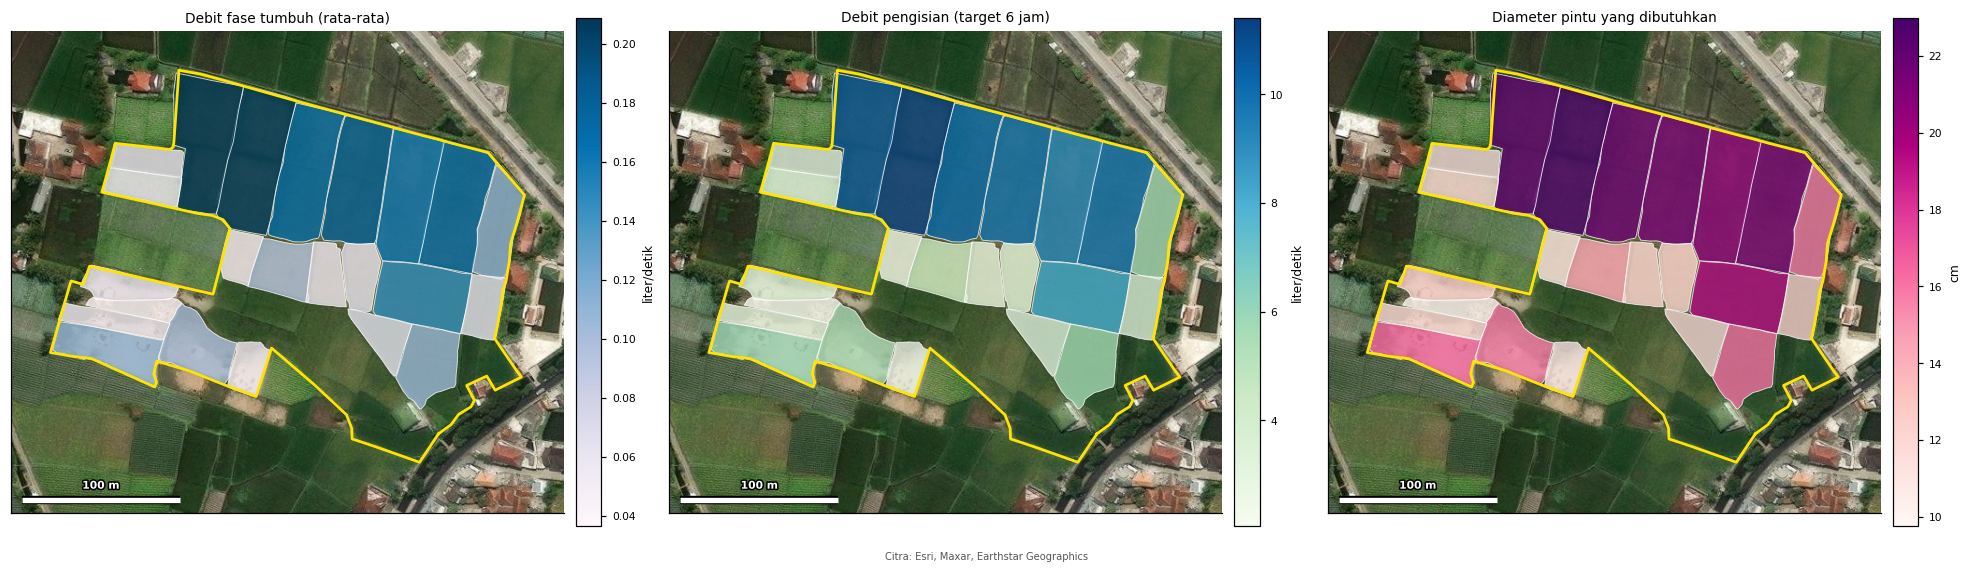

In [36]:
fig, axes = plt.subplots(1, 3, figsize=ukuran_peta(3, 18.0))
peta_petak(deb["debit_l_detik"], "Debit fase tumbuh (rata-rata)", "liter/detik",
           cmap="PuBu", ax=axes[0])
peta_petak(deb["Q_isi_l_detik"], f"Debit pengisian (target {LAMA_ISI_JAM:.0f} jam)",
           "liter/detik", cmap="GnBu", ax=axes[1])
peta_petak(deb["diameter_cm"], "Diameter pintu yang dibutuhkan", "cm",
           cmap="RdPu", ax=axes[2])
fig.text(0.5, 0.005, KREDIT if BASEMAP is not None else "(tanpa citra satelit)",
         ha="center", fontsize=6.5, color="#555")
plt.tight_layout(rect=[0, 0.02, 1, 1])
simpan_gambar(fig, "04_debit_dan_pintu"); plt.show()

---
## 8. Water loss per petak  ← pertanyaan 3

Air yang masuk keluar lewat **tiga pintu**:

| Jalur | Hilang betulan? |
|---|---|
| **Menguap** (ETc) | Ya — tapi ini yang **produktif**, bikin padi tumbuh |
| **Meresap** (perkolasi) | Sebagian; bisa mengisi air tanah |
| **Mengalir keluar** (limpasan) | Bisa dipakai lagi petak di bawahnya |

Yang benar-benar merugikan adalah **limpasan berlebih** — terbuang tanpa dipakai,
dan ikut membawa pupuk keluar.

Persen dihitung terhadap **total keluar**, jadi selalu berjumlah 100% di tiap petak.

In [37]:
wl = ringkasan.copy()
wl["masuk_mm"]  = wl["hujan_mm"] + wl["irigasi_mm"]
wl["keluar_mm"] = wl["etc_mm"] + wl["perkolasi_mm"] + wl["limpasan_mm"]
wl["delta_simpanan_mm"] = wl["masuk_mm"] - wl["keluar_mm"]
for k in ("etc", "perkolasi", "limpasan"):
    wl[f"{k}_pct"] = 100*wl[f"{k}_mm"]/wl["keluar_mm"]
wlf = wl[wl.rezim == "FL" ].set_index("id_petak")
wls = wl[wl.rezim == "SRI"].set_index("id_petak")

print("=" * 78)
print(f"            WATER LOSS — {N_PETAK} PETAK, {LUAS_PETAK_HA:.2f} ha")
print("=" * 78)
for nm, d in [("FL (genangan)", wlf), ("SRI (basah-kering)", wls)]:
    print(f"\n  {nm}   (air masuk {d['masuk_mm'].mean():.0f} mm, "
          f"perubahan simpanan {d['delta_simpanan_mm'].mean():+.0f} mm)")
    print(f"    {'jalur':<26}{'mm (rata)':>12}{'m3 total':>12}{'% keluar':>11}"
          f"{'sebaran mm':>18}")
    print("    " + "-"*70)
    for lbl, k in [("Menguap (ETc)", "etc"), ("Meresap (perkolasi)", "perkolasi"),
                   ("Mengalir keluar", "limpasan")]:
        print(f"    {lbl:<26}{d[k+'_mm'].mean():>12.1f}{d[k+'_m3'].sum():>12,.0f}"
              f"{d[k+'_pct'].mean():>10.1f}%"
              f"{d[k+'_mm'].min():>9.0f} -{d[k+'_mm'].max():>7.0f}")
    print("    " + "-"*70)
    print(f"    {'TOTAL KELUAR':<26}{d['keluar_mm'].mean():>12.1f}"
          f"{(d['etc_m3']+d['perkolasi_m3']+d['limpasan_m3']).sum():>12,.0f}{100.0:>10.1f}%")
print("=" * 78)

            WATER LOSS — 23 PETAK, 3.39 ha

  FL (genangan)   (air masuk 646 mm, perubahan simpanan -22 mm)
    jalur                        mm (rata)    m3 total   % keluar        sebaran mm
    ----------------------------------------------------------------------
    Menguap (ETc)                    510.8      17,300      76.6%      511 -    511
    Meresap (perkolasi)              124.2       4,052      18.4%       73 -    211
    Mengalir keluar                   33.1       1,145       5.0%       24 -     41
    ----------------------------------------------------------------------
    TOTAL KELUAR                     668.1      22,498     100.0%

  SRI (basah-kering)   (air masuk 625 mm, perubahan simpanan -37 mm)
    jalur                        mm (rata)    m3 total   % keluar        sebaran mm
    ----------------------------------------------------------------------
    Menguap (ETc)                    488.5      16,545      74.0%      488 -    488
    Meresap (perkolasi)    

[gambar] 05_water_loss_mm.png             1,194 KB


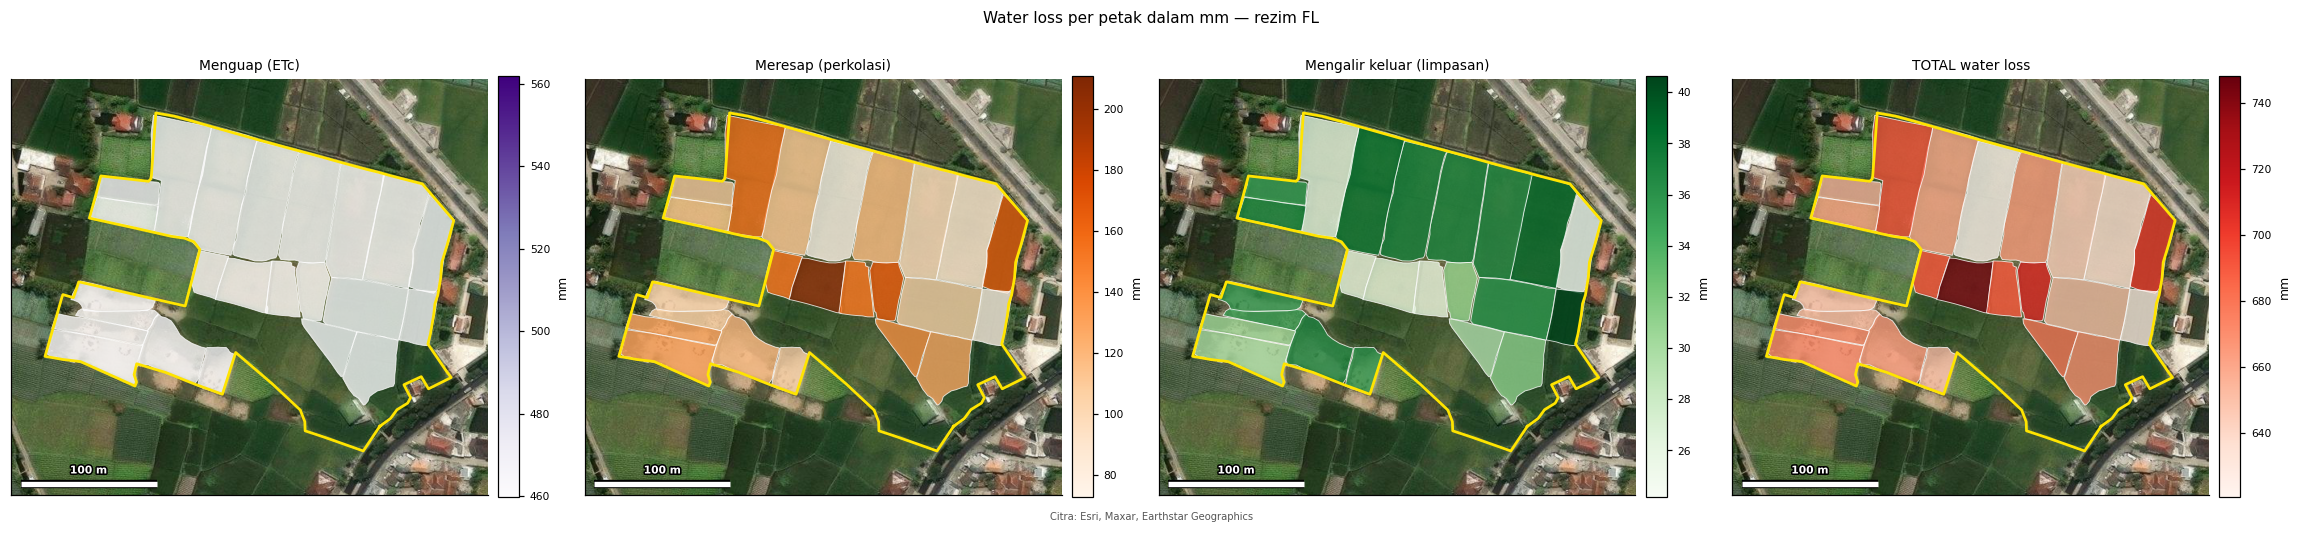

[gambar] 06_water_loss_persen.png         1,249 KB


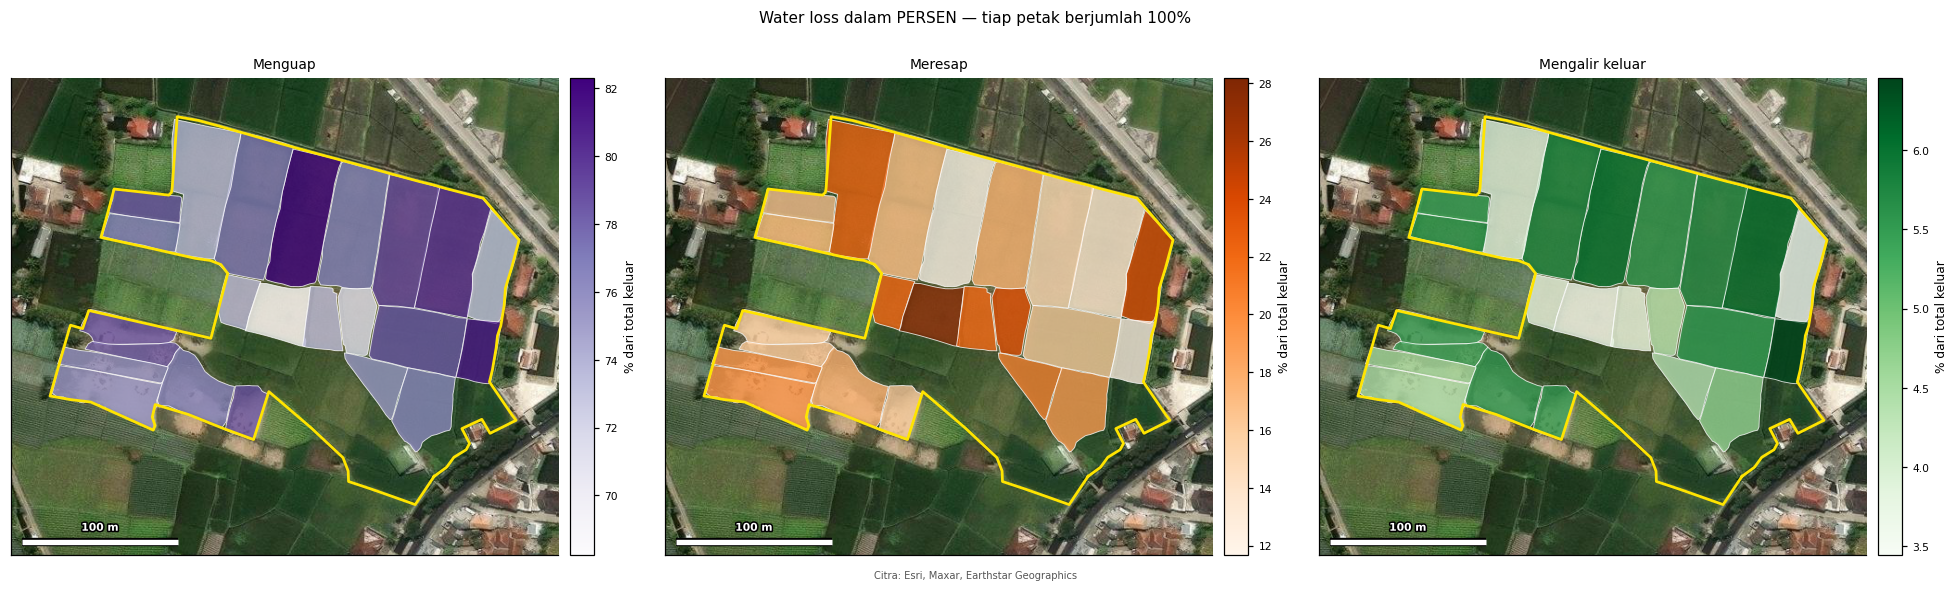

Menguap  :  68.3% -  82.3%   (sebaran 14.0 poin) <- hampir seragam, cuacanya sama
Meresap  :  11.7% -  28.2%   (sebaran 16.5 poin) <- PALING beragam, tanahnya beda
Keluar   :   3.4% -   6.5%   (sebaran 3.0 poin)


In [38]:
fl_total = wlf["etc_mm"] + wlf["perkolasi_mm"] + wlf["limpasan_mm"]

fig, axes = plt.subplots(1, 4, figsize=ukuran_peta(4, 21.0))
peta_petak(wlf["etc_mm"],       "Menguap (ETc)",             "mm", cmap="Purples", ax=axes[0])
peta_petak(wlf["perkolasi_mm"], "Meresap (perkolasi)",       "mm", cmap="Oranges", ax=axes[1])
peta_petak(wlf["limpasan_mm"],  "Mengalir keluar (limpasan)","mm", cmap="Greens",  ax=axes[2])
peta_petak(fl_total,            "TOTAL water loss",          "mm", cmap="Reds",    ax=axes[3])
fig.suptitle("Water loss per petak dalam mm — rezim FL", fontsize=10, y=1.00)
fig.text(0.5, 0.005, KREDIT if BASEMAP is not None else "(tanpa citra satelit)",
         ha="center", fontsize=6.5, color="#555")
plt.tight_layout(rect=[0, 0.02, 1, 0.96])
simpan_gambar(fig, "05_water_loss_mm"); plt.show()

fig, axes = plt.subplots(1, 3, figsize=ukuran_peta(3, 18.0))
peta_petak(wlf["etc_pct"],       "Menguap",         "% dari total keluar", cmap="Purples", ax=axes[0])
peta_petak(wlf["perkolasi_pct"], "Meresap",         "% dari total keluar", cmap="Oranges", ax=axes[1])
peta_petak(wlf["limpasan_pct"],  "Mengalir keluar", "% dari total keluar", cmap="Greens",  ax=axes[2])
fig.suptitle("Water loss dalam PERSEN — tiap petak berjumlah 100%", fontsize=10, y=1.00)
fig.text(0.5, 0.005, KREDIT if BASEMAP is not None else "(tanpa citra satelit)",
         ha="center", fontsize=6.5, color="#555")
plt.tight_layout(rect=[0, 0.02, 1, 0.96])
simpan_gambar(fig, "06_water_loss_persen"); plt.show()

print(f"Menguap  : {wlf['etc_pct'].min():5.1f}% - {wlf['etc_pct'].max():5.1f}%"
      f"   (sebaran {wlf['etc_pct'].max()-wlf['etc_pct'].min():.1f} poin) <- hampir seragam, cuacanya sama")
print(f"Meresap  : {wlf['perkolasi_pct'].min():5.1f}% - {wlf['perkolasi_pct'].max():5.1f}%"
      f"   (sebaran {wlf['perkolasi_pct'].max()-wlf['perkolasi_pct'].min():.1f} poin) <- PALING beragam, tanahnya beda")
print(f"Keluar   : {wlf['limpasan_pct'].min():5.1f}% - {wlf['limpasan_pct'].max():5.1f}%"
      f"   (sebaran {wlf['limpasan_pct'].max()-wlf['limpasan_pct'].min():.1f} poin)")

---
## 9. Ekspor hasil

Semua tabel, geometri, dan **gambar** disimpan ke `note/output-swh/`.
Gambar tiap figure (lengkap dengan seluruh subplot-nya) masuk ke
`note/output-swh/gambar/` sebagai PNG 150 dpi.

In [39]:
luas_map = dict(zip(petak["id_petak"], petak["luas_m2"]))
geo = []
for pid, poly in bagian:
    geo.append({"id_petak": pid, "luas_petak_m2": round(luas_map[pid], 2),
                "luas_bagian_m2": round(luas_shoelace(poly), 2),
                "koordinat": [[round(px/M_PER_DEG_LON + lon0, 8),
                               round(py/M_PER_DEG_LAT + lat0, 8)] for px, py in poly]})

for nama, df in {"petak.csv": petak, "cuaca_harian.csv": cuaca,
                 "neraca_harian.csv": harian, "ringkasan_petak.csv": ringkasan,
                 "kebutuhan_air_debit.csv": deb.reset_index(),
                 "water_loss.csv": wl}.items():
    df.to_csv(OUT_DIR / nama, index=False)
    print(f"  {nama:<26} {len(df):>7,} baris")

(OUT_DIR / "petak_geometri.json").write_text(json.dumps(
    {"sumber_kml": KML.name, "crs": "EPSG:4326", "asal_petak": "digitasi di KML",
     "jumlah_petak": N_PETAK,
     "luas_total_m2": round(LUAS_M2, 2), "luas_total_ha": round(LUAS_HA, 5),
     "luas_petak_total_m2": round(LUAS_PETAK_M2, 2),
     "luas_petak_total_ha": round(LUAS_PETAK_HA, 5),
     "cakupan_petak_pct": round(CAKUPAN_PCT, 2),
     "petak": geo}, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"  {'petak_geometri.json':<26} {N_PETAK:>7,} petak")

def warna_kml(rgba, alfa=0.62):
    r, g, b = (int(round(255*c)) for c in rgba[:3])
    return f"{int(round(255*alfa)):02x}{b:02x}{g:02x}{r:02x}"

def tulis_kml(berkas, nilai, judul, satuan, cmap="YlOrRd"):
    v = {p: float(nilai[p]) for p in petak["id_petak"]}
    norm = plt.Normalize(min(v.values()), max(v.values())); cm = plt.get_cmap(cmap)
    gaya, tempat = [], []
    ptk = petak.set_index("id_petak")
    for pid in petak["id_petak"]:
        gaya.append(f'    <Style id="s_{pid}"><LineStyle><color>ffffffff</color>'
                    f'<width>1.2</width></LineStyle><PolyStyle>'
                    f'<color>{warna_kml(cm(norm(v[pid])))}</color></PolyStyle></Style>')
    for pid, poly in bagian:
        val = v[pid]; r = ptk.loc[pid]
        t = [(px/M_PER_DEG_LON + lon0, py/M_PER_DEG_LAT + lat0) for px, py in poly]
        t.append(t[0])
        koord = " ".join(f"{lo:.8f},{la:.8f},0" for lo, la in t)
        f_, d_ = wlf.loc[pid], deb.loc[pid]
        info = ("<![CDATA[" f"<b>{judul}: {val:,.1f} {satuan}</b><br/><hr/>"
                f"Luas: {r['luas_m2']:,.0f} m2 = {r['luas_ha']:.4f} ha<br/>"
                f"Perkolasi: {r['a_perkolasi']:.2e} /detik<br/><hr/>"
                f"<b>Kebutuhan air (FL)</b><br/>"
                f"&nbsp;{f_['irigasi_mm']:,.0f} mm = {f_['irigasi_m3']:,.1f} m3<br/>"
                f"&nbsp;Debit tumbuh: {d_['debit_l_detik']:.3f} l/dt<br/>"
                f"&nbsp;Debit isi ({LAMA_ISI_JAM:.0f} jam): {d_['Q_isi_l_detik']:.2f} l/dt<br/>"
                f"&nbsp;Diameter pintu: {d_['diameter_cm']:.0f} cm<br/><hr/>"
                f"<b>Water loss</b><br/>"
                f"&nbsp;Menguap : {f_['etc_mm']:,.0f} mm ({f_['etc_pct']:.0f}%)<br/>"
                f"&nbsp;Meresap : {f_['perkolasi_mm']:,.0f} mm ({f_['perkolasi_pct']:.0f}%)<br/>"
                f"&nbsp;Mengalir: {f_['limpasan_mm']:,.0f} mm ({f_['limpasan_pct']:.0f}%)"
                "]]>")
        tempat.append(f'    <Placemark><name>{pid}</name><description>{info}</description>'
                      f'<styleUrl>#s_{pid}</styleUrl><Polygon><outerBoundaryIs><LinearRing>'
                      f'<coordinates>{koord}</coordinates>'
                      f'</LinearRing></outerBoundaryIs></Polygon></Placemark>')
    berkas.write_text('<?xml version="1.0" encoding="UTF-8"?>\n'
        '<kml xmlns="http://www.opengis.net/kml/2.2">\n  <Document>\n'
        f'    <name>SWH-011 — {judul}</name>\n'
        + "\n".join(gaya) + "\n" + "\n".join(tempat) + "\n  </Document>\n</kml>\n",
        encoding="utf-8")
    return berkas

for nama, nilai, judul, satuan, cmap in [
        ("swh011_kebutuhan_air.kml", wlf["irigasi_mm"],   "Kebutuhan air (FL)", "mm/musim", "YlGnBu"),
        ("swh011_water_loss.kml",    fl_total,            "Total water loss",   "mm/musim", "Reds"),
        ("swh011_debit_pengisian.kml", deb["Q_isi_l_detik"], "Debit pengisian", "l/detik",  "GnBu")]:
    f = tulis_kml(OUT_DIR / nama, nilai, judul, satuan, cmap)
    print(f"  {nama:<26} {f.stat().st_size:>7,} byte")
print(f"\n  {len(GAMBAR_TERSIMPAN)} gambar di {GBR_DIR.name}/")
for _g in GAMBAR_TERSIMPAN:
    print(f"    {_g.name:<30} {_g.stat().st_size:>9,} byte")
if len(GAMBAR_TERSIMPAN) < 6:
    print("    (jalankan Run All - gambar hanya tersimpan saat sel petanya dieksekusi)")
print(f"\nSemua tersimpan di: {OUT_DIR}")

  petak.csv                       23 baris
  cuaca_harian.csv               110 baris
  neraca_harian.csv            5,060 baris
  ringkasan_petak.csv             46 baris
  kebutuhan_air_debit.csv         23 baris
  water_loss.csv                  46 baris
  petak_geometri.json             23 petak
  swh011_kebutuhan_air.kml    32,673 byte
  swh011_water_loss.kml       32,625 byte
  swh011_debit_pengisian.kml  32,535 byte

  6 gambar di gambar/
    01_isi_batas_luar.png            136,131 byte
    02_petak_luas_perkolasi.png    1,065,333 byte
    03_kebutuhan_air.png           1,040,715 byte
    04_debit_dan_pintu.png         1,297,232 byte
    05_water_loss_mm.png           1,222,235 byte
    06_water_loss_persen.png       1,279,096 byte

Semua tersimpan di: d:\WMS_AgrinIrigation\note\output-swh


---
## 10. Ringkasan

In [40]:
print("=" * 72)
print(f"                    RINGKASAN — {batas['nama']}")
print("=" * 72)
print(f"\n  LAHAN")
print(f"    Lokasi        : {lat0:.5f} LS, {lon0:.5f} BT")
print(f"    Batas luar    : {LUAS_M2:,.0f} m2 = {LUAS_HA:.2f} ha = {LUAS_KM2:.6f} km2")
print(f"    Isi file KML  : 1 poligon batas luar + {N_PETAK} poligon petak")
print(f"    JUMLAH PETAK  : {N_PETAK}  (DIBACA dari {KML.name})")
print(f"    Luas petak    : {LUAS_PETAK_M2:,.0f} m2 = {LUAS_PETAK_HA:.2f} ha "
      f"= {CAKUPAN_PCT:.0f}% batas luar")
print(f"                    {petak['luas_m2'].min():,.0f}-{petak['luas_m2'].max():,.0f} m2, "
      f"median {petak['luas_m2'].median():,.0f} m2")
print(f"    Bukan petak   : {LUAS_M2-LUAS_PETAK_M2:,.0f} m2 -> "
      f"{LUAS_TIPIS:,.0f} m2 galengan/jalan + {LUAS_BELUM:,.0f} m2 BELUM DIPETAKAN")

print(f"\n  1. KEBUTUHAN AIR ({N_HARI} hari, hujan {cuaca['hujan_mm'].sum():.0f} mm)")
print(f"    {'':<24}{'FL':>16}{'SRI':>16}")
print(f"    {'-'*56}")
for lbl, a, b in [
    ("Per petak (mm)",  f"{fl['irigasi_mm'].min():.0f}-{fl['irigasi_mm'].max():.0f}",
                        f"{sri['irigasi_mm'].min():.0f}-{sri['irigasi_mm'].max():.0f}"),
    ("Per petak (m3)",  f"{fl['irigasi_m3'].min():.0f}-{fl['irigasi_m3'].max():.0f}",
                        f"{sri['irigasi_m3'].min():.0f}-{sri['irigasi_m3'].max():.0f}"),
    ("Seluruh petak (mm)", f"{fl['irigasi_m3'].sum()/(LUAS_PETAK_M2/1000):,.0f}",
                           f"{sri['irigasi_m3'].sum()/(LUAS_PETAK_M2/1000):,.0f}"),
    ("Seluruh petak (m3)", f"{fl['irigasi_m3'].sum():,.0f}",
                           f"{sri['irigasi_m3'].sum():,.0f}")]:
    print(f"    {lbl:<24}{a:>16}{b:>16}")

print(f"\n  2. DEBIT")
print(f"    Fase tumbuh (DR)      : {dr_tumbuh:8.3f} l/detik/ha "
      f"-> {dr_tumbuh*LUAS_PETAK_HA:6.2f} l/detik total")
print(f"    Penyiapan lahan       : {deb['dr_pl_l_detik_ha'].max():8.3f} l/detik/ha "
      f"-> {deb['debit_pl_l_detik'].sum():6.2f} l/detik total")
print(f"    Pengisian {LAMA_ISI_JAM:.0f} jam        : "
      f"{deb['Q_isi_l_detik'].sum()/LUAS_PETAK_HA:8.1f} l/detik/ha "
      f"-> {deb['Q_isi_l_detik'].sum():6.1f} l/detik total")
print(f"    Diameter pintu        : {deb['diameter_cm'].min():.0f} - "
      f"{deb['diameter_cm'].max():.0f} cm")

print(f"\n  3. WATER LOSS (FL)")
print(f"    {'jalur':<24}{'mm':>10}{'m3':>12}{'%':>8}")
print(f"    {'-'*54}")
for lbl, k in [("Menguap (ETc)", "etc"), ("Meresap (perkolasi)", "perkolasi"),
               ("Mengalir keluar", "limpasan")]:
    print(f"    {lbl:<24}{wlf[k+'_mm'].mean():>10.0f}{wlf[k+'_m3'].sum():>12,.0f}"
          f"{wlf[k+'_pct'].mean():>7.1f}%")
print("\n" + "=" * 72)

                    RINGKASAN — SWH-011

  LAHAN
    Lokasi        : -7.18254 LS, 107.90794 BT
    Batas luar    : 42,877 m2 = 4.29 ha = 0.042877 km2
    Isi file KML  : 1 poligon batas luar + 23 poligon petak
    JUMLAH PETAK  : 23  (DIBACA dari SWH-011_lengkap.kml)
    Luas petak    : 33,872 m2 = 3.39 ha = 79% batas luar
                    548-3,030 m2, median 1,195 m2
    Bukan petak   : 9,006 m2 -> 1,835 m2 galengan/jalan + 7,508 m2 BELUM DIPETAKAN

  1. KEBUTUHAN AIR (110 hari, hujan 216 mm)
                                          FL             SRI
    --------------------------------------------------------
    Per petak (mm)                   390-509         339-488
    Per petak (m3)                  226-1290        206-1275
    Seluruh petak (mm)                   427             404
    Seluruh petak (m3)                14,468          13,686

  2. DEBIT
    Fase tumbuh (DR)      :    0.691 l/detik/ha ->   2.34 l/detik total
    Penyiapan lahan       :    2.558 l/detik/ha

---
## 11. Asumsi — **baca sebelum memakai angka di atas**

### Dari data nyata

| Apa | Nilai | Sumber |
|---|---|---|
| **Jumlah, bentuk, luas petak** | 23 petak, 3,39 ha | digitasi `SWH-011_lengkap.kml` |
| Kc per fase | 1,01 / 1,02 / 1,09 / 1,05 (FL) | Arif Tabel 1 |
| Rumus ETo Hargreaves | pers. (1) | Arif |
| Rentang koefisien perkolasi | 4,0e-7 – 1,6e-6 /detik | Li §2.3 |
| Rumus limpasan & orifice | pers. (4), (7)–(8) | Li |
| Penyiapan lahan, DR, efisiensi 0,65 | van de Goor & Zijlstra | KP-01 |

### Yang **dikarang** dan perlu diganti data lapangan

| Asumsi | Dipakai | Pengaruh |
|---|---|---|
| **Cuaca 110 hari** | dibangkitkan acak (seed 20260810) | **Besar** — ganti data BMKG/stasiun |
| **Sebaran perkolasi** | medan acak halus, median 8,0e-7 /detik | **Besar** — Li mengukur di terasering Jepang, bukan di sini |
| **Perkolasi saat kering** | 60% dari laju tergenang | **Besar** — belum pernah diukur di mana pun |
| **Panjang fase** 20/30/40/20 hari | perkiraan Ciherang ±110 hari | Sedang |
| **Setpoint TMA per fase** | dari deskripsi Arif §2.1 | Sedang |
| **θ jenuh 0,50 / θ awal 0,30** | tanah sawah lempung | Sedang — memengaruhi air pengisian awal |
| **Efisiensi 0,65** | nilai umum KP-01 | Besar untuk DR |
| **Semua petak satu varietas** | Ciherang, tanam serempak | Sedang |

> Dibanding versi `SWH-011.kml`, asumsi terbesar yang **sudah lunas** adalah pembagian
> petak: dulu grid otomatis 1.000 m² di atas seluruh batas luar, sekarang 23 petak asli
> dengan luas 547–3.030 m². Luas yang diairi ikut berubah: **3,39 ha (petak)**, bukan
> 4,29 ha (batas luar).
>
> **Asumsi baru yang muncul dari file ini:** ±0,75 ha di dalam batas luar tidak punya
> poligon petak dan terlalu lebar untuk galengan (bagian 3). Notebook menganggap daerah
> itu **bukan sawah**. Kalau ternyata sawah, seluruh angka air di sini kurang sekitar
> **20%** — ini yang pertama harus dipastikan di lapangan.

### Penyederhanaan

1. **Tiap petak berdiri sendiri.** Limpasan petak atas belum dialirkan ke petak bawah.
   Urutan hulu–hilir belum bisa ditentukan karena saluran belum digambar di KML.
2. **Tidak ada jaringan saluran.** Kehilangan penyaluran hanya diwakili angka efisiensi.
3. **Semua petak ditanam serempak.** Citra satelit menunjukkan tanam **tidak serempak**
   di kawasan ini — kalau begitu, debit puncak nyata lebih rendah dari hitungan di sini.
4. **Lahan dianggap datar** untuk hitungan luas. Untuk lokasi ini itu benar
   (kemiringan < 1%, bukan terasering) — jadi mekanisme *tagoshi* di paper Li
   **tidak berlaku** dan sengaja tidak dipakai.
5. **Tumpang tindih galengan dibiarkan.** Petak bersebelahan bisa berbagi galengan yang
   sama; luasnya dipakai apa adanya karena selisihnya < 1% (lihat pemeriksaan bagian 3).

### Cara mengukur perkolasi di lapangan (menutup asumsi terbesar)

Pasang sensor TMA, baca laju penurunan air antara **jam 22.00–04.00** pada malam tanpa
hujan dan tanpa irigasi. Jam segitu penguapan hampir nol, jadi seluruh penurunan air
= perkolasi murni. Ulangi saat tergenang dan saat kering → rasionya langsung ketahuan.

Syaratnya sensor harus bisa membaca perubahan **≤ 0,5 mm**. Sensor ultrasonik murah
(ketelitian ±1 cm) tidak akan bisa — ini menentukan pilihan perangkat keras.